<a href="https://colab.research.google.com/github/birsensarem/Birsen_Data/blob/main/Veri_Analizi_Okulu_Yapay_Zeka_Dil_Modelleri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Veri Analizi Okulu – Yapay Zeka
## Dil Modelleri

**Hazırlayan:** Emre Fişne  
**Kurum:** Boğaziçi Üniversitesi / Veri Bilimi ve Yapay Zeka Enstitüsü

**Tarih:** 29 Nisan 2026

---
Bu notebook, Büyük Dil Modelleri ile metin sınıflandırma problemini pratik bir örnek üzerinden incelemek amacıyla hazırlanmıştır. Çalışma boyunca aynı veri kümesi üzerinde sırasıyla **Zero-shot**, **Few-shot**, **Chain-of-Thought (CoT)** ve **Reflexion** yaklaşımları uygulanarak, farklı prompt engineering stratejilerinin model davranışı ve sınıflandırma performansı üzerindeki etkisi gözlemlenecektir. Böylece, yalnızca prompt tasarımındaki değişimlerin bile model çıktısını ne ölçüde yönlendirebildiği somut olarak gösterilmesi hedeflenmektedir.

## İçindekiler

1. **Ekosistem**
2. **Büyük Dil Modelleri ile Metin Sınıflandırma Problemi**
3. **Veri Seti ve Etiket Yapısının Tanıtılması**
4. **Zero-shot Prompting**
5. **Few-shot Prompting**
6. **Chain-of-Thought (CoT) Yaklaşımı**
7. **Reflexion ile Öz-Denetimli Gözden Geçirme**
7. **Supervised fine-tuning**
7. **Deployment (Ollama)**
8. **Yöntemlerin Karşılaştırılması**
9. **Sonuçlar ve Kısa Değerlendirme**

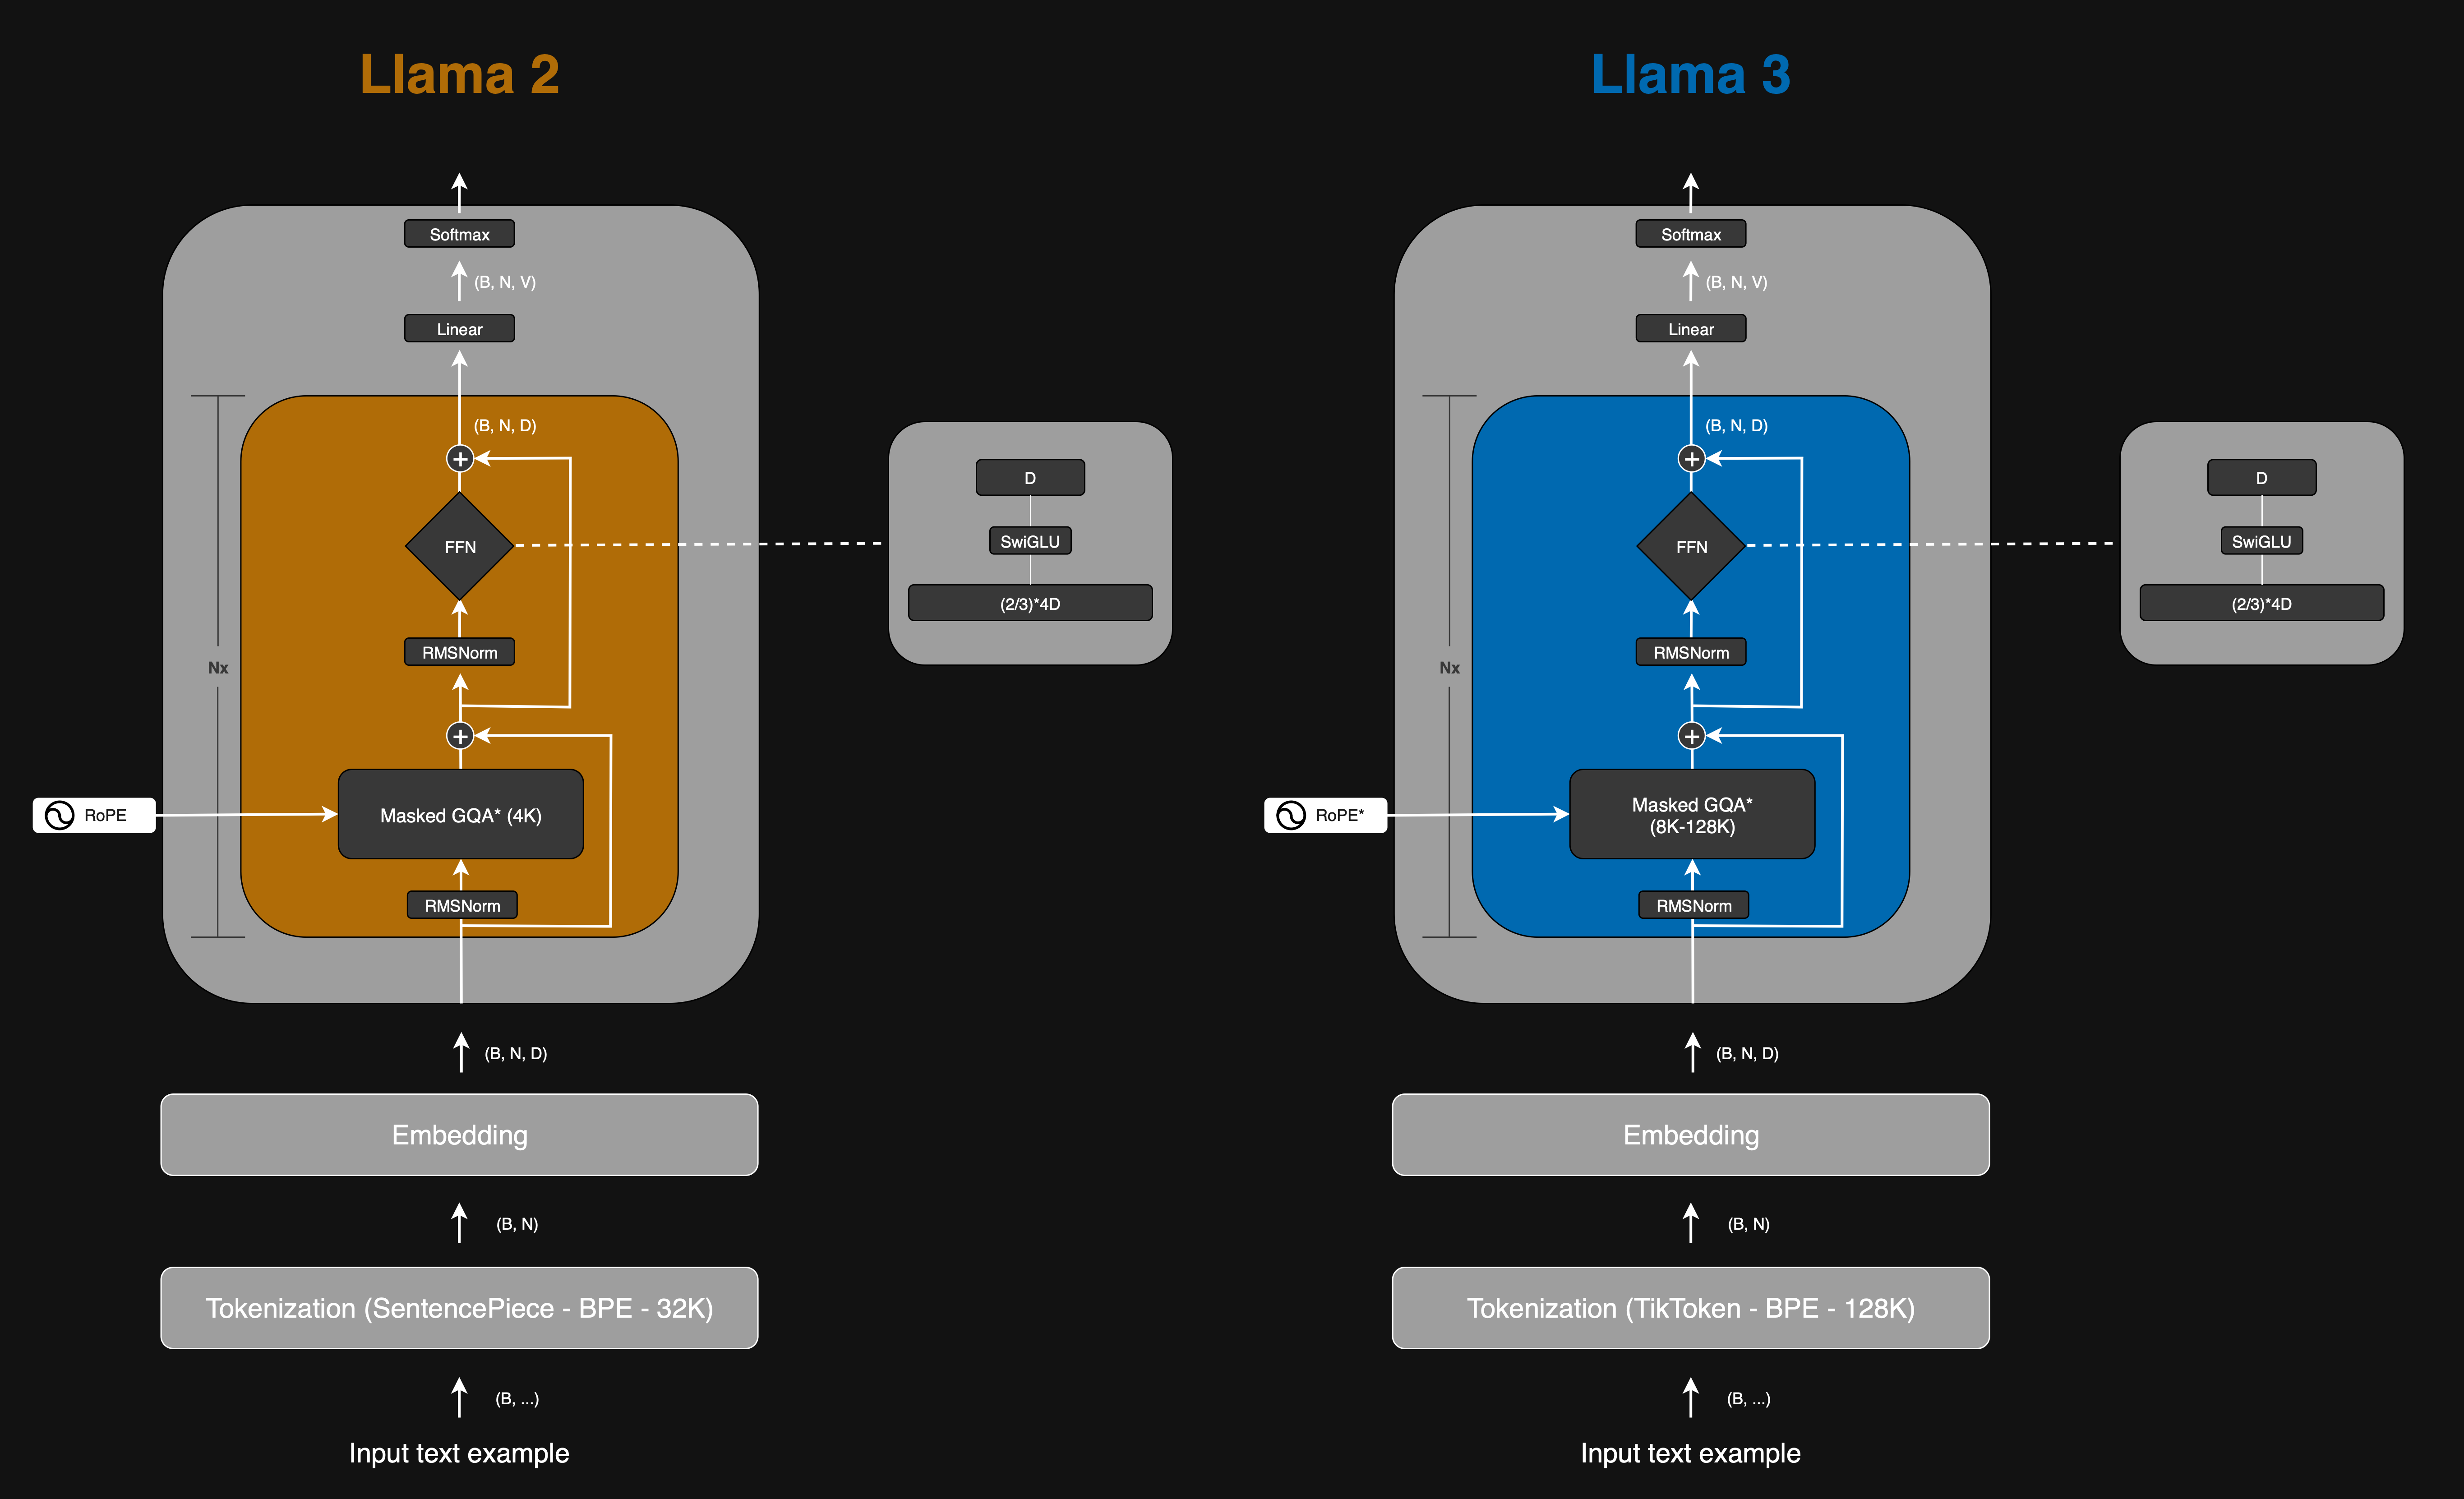

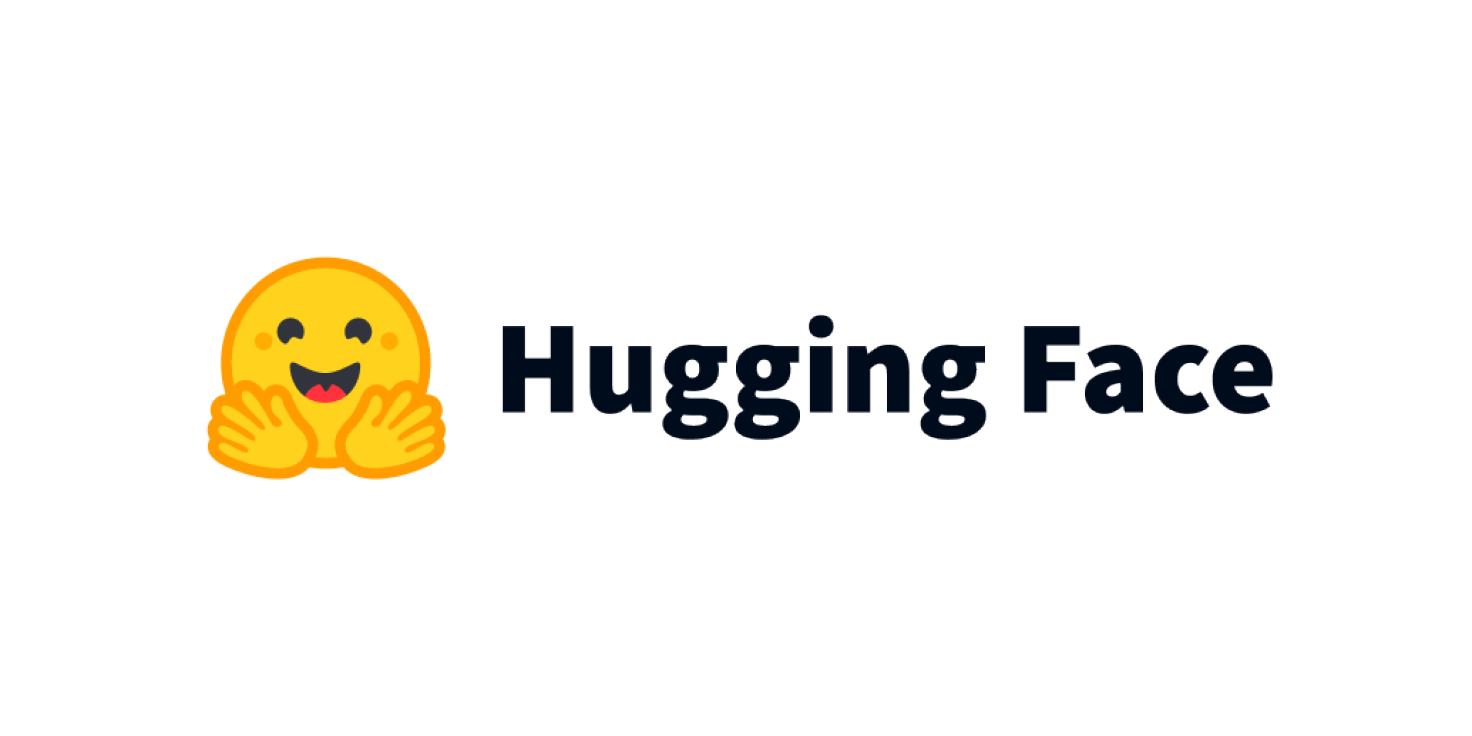

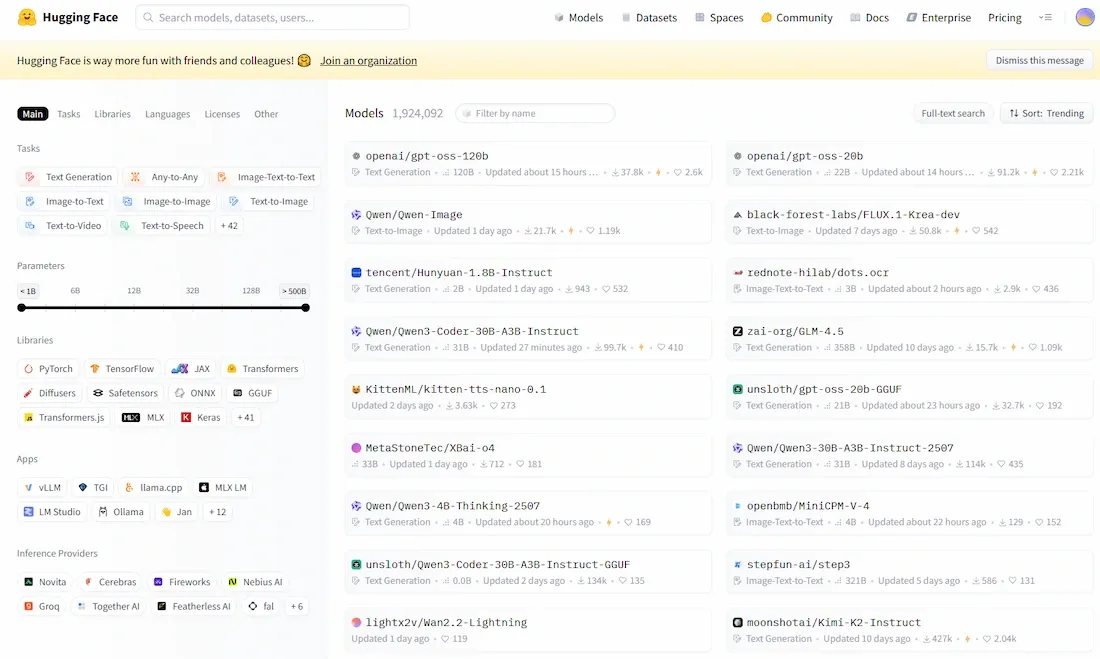

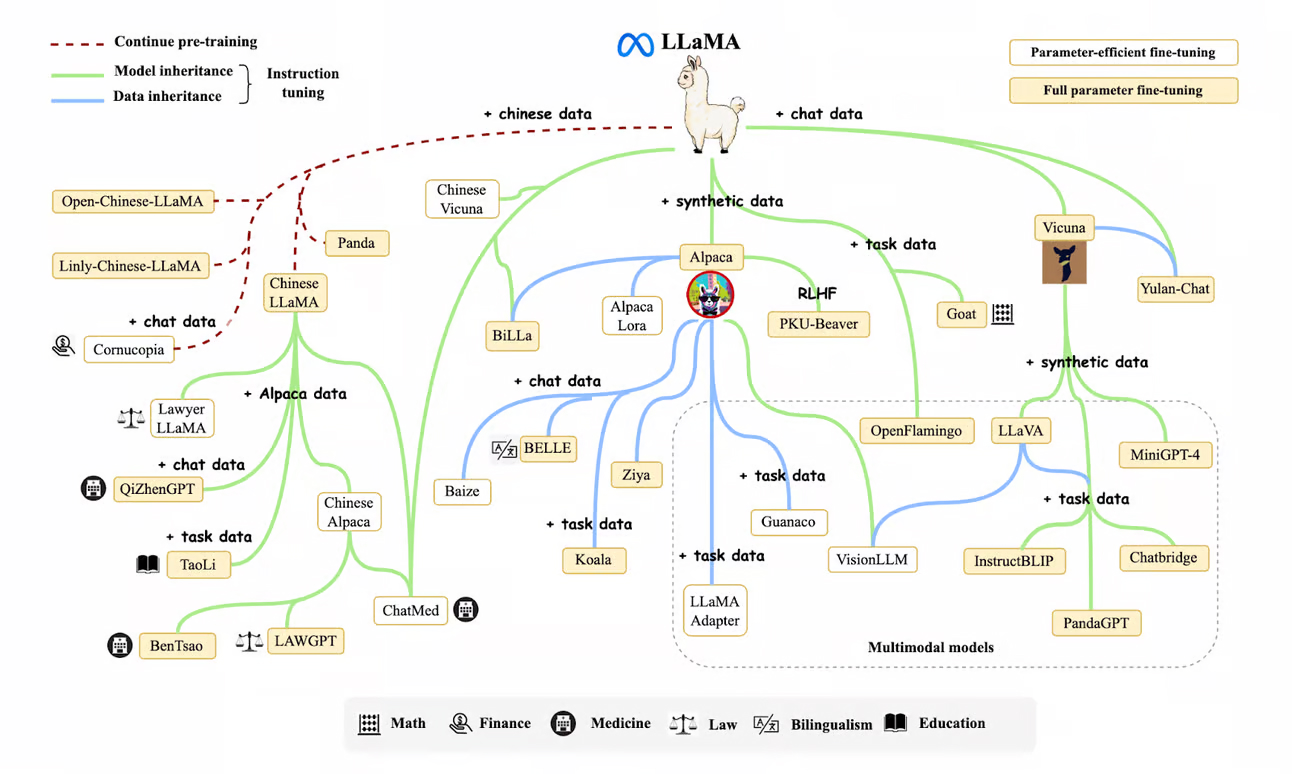

### **Llama 3 nedir?**

* Güncel ve güçlü (SOTA), açık kaynak bir BDM
* 8B, 70B
* Model seçerken düşünülmesi gerekenler: Boyut, kalite, maliyet, hız
* Pretrained + Chat / Instruct sürümleri
* [Meta Llama 3 Blog](https://ai.meta.com/blog/meta-llama-3/)
* [Meta Llama ile Başlangıç](https://llama.meta.com/docs/get-started)

Bu bölümde önce modeli ve ekosistemi kısaca tanıyacağız. Ardından aynı görev üzerinde farklı prompting yaklaşımlarını karşılaştıracağız.


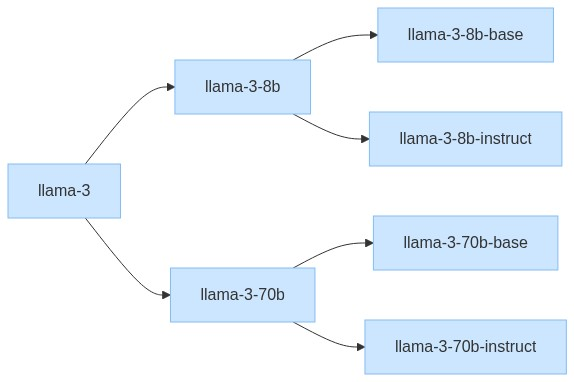

### **Llama 3’e erişim**
* self-host ([Llama indir](https://ai.meta.com/resources/models-and-libraries/llama-downloads))
* Hosting API platformları (örn. [Replicate](https://replicate.com/meta/meta-llama-3-8b-instruct), [Together](https://api.together.xyz/playground/language/meta-llama/Llama-3-8b-chat-hf), [Groq](https://console.groq.com/playground?model=llama3-8b-8192))

Pratik oturum açısından burada önemli olan nokta şu: aynı modeli farklı erişim yollarıyla kullanabiliriz. Biz burada, kurulumu kolaylaştırmak için hosting servis kullanacağız.


## **Llama 3 ve Llama 2’yi kullanma ve karşılaştırma**

Bu notebook’ta, [Replicate](https://replicate.com/blog/run-llama-3-with-an-api?input=python) üzerinde barındırılan Llama 2 7b chat ve Llama 3 8b instruct modellerini kullanacağız. Önce [giriş yapmanız](https://replicate.com/signin) ve ardından Replicate API anahtarınızı oluşturmanız gerekir.

Bu ilk kısımda amaç sadece çıktı almak değil; aynı zamanda iki modelin aynı komutlara nasıl farklı tepki verdiğini gözlemlemektir. Böylece daha sonra prompt engineering kısmında neden bazı tekniklerin işe yaradığını daha somut görebileceğiz.


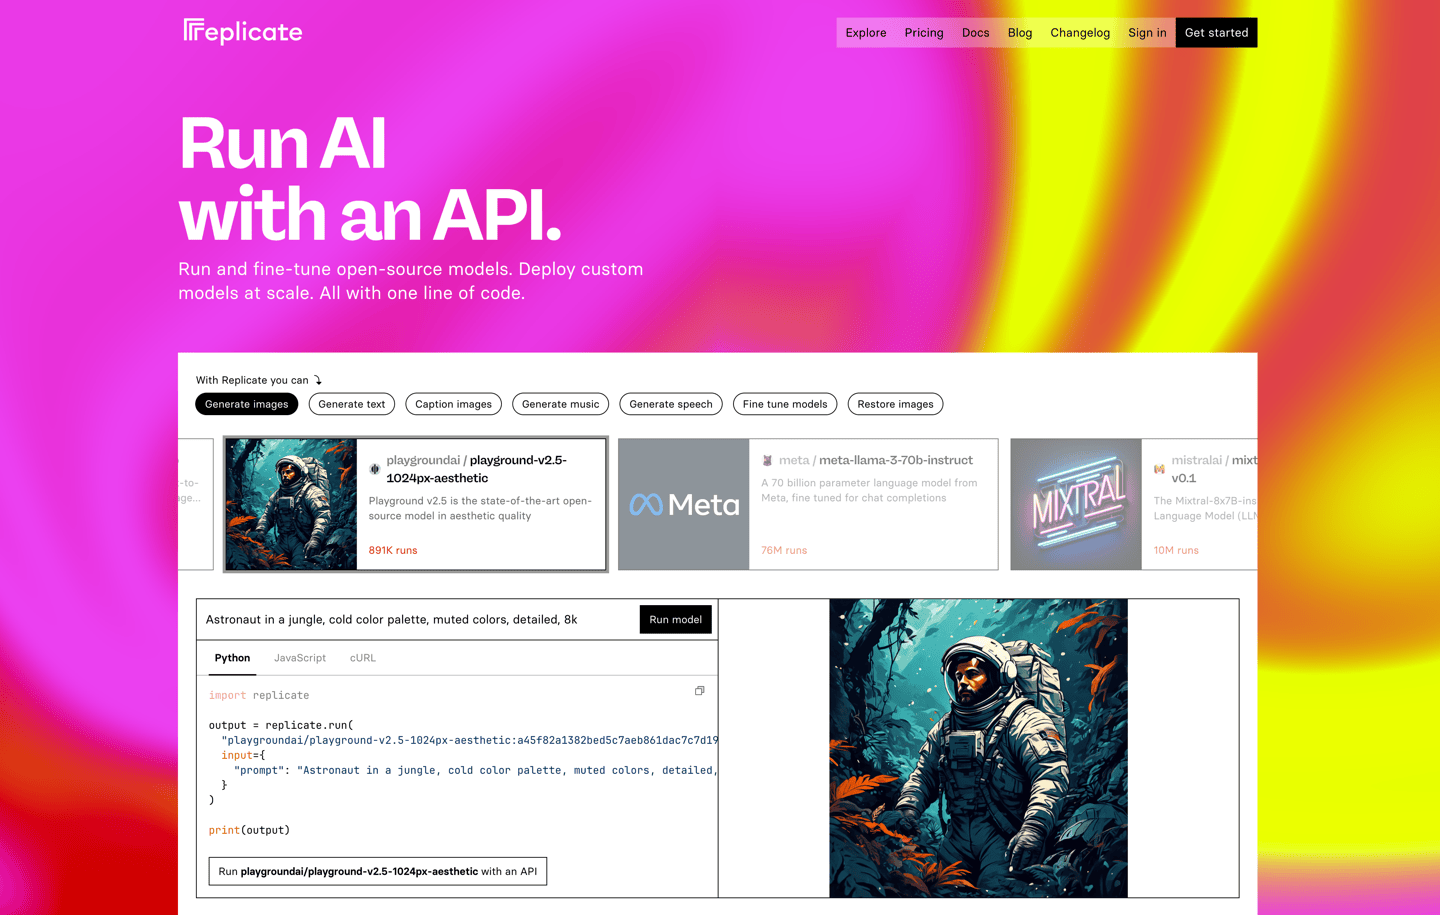

### **Bağımlılıkları kurma**


In [ ]:
!pip install replicate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 6.7 MB/s eta 0:00:00


### **Llama 2 ve Llama 3 için yardımcı fonksiyonları oluşturma**


Önce Replicate API anahtarınızı ortam değişkeni olarak ayarlayın.


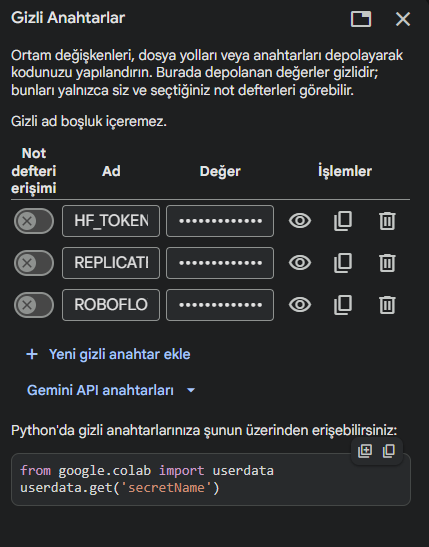

In [ ]:
import os
from getpass import getpass

REPLICATE_API_TOKEN = getpass()

os.environ["REPLICATE_API_TOKEN"] = REPLICATE_API_TOKEN

··········


Llama 2 ve Llama 3 için yardımcı fonksiyonları oluşturalım. Bu derste base modeller yerine Llama 3 8b/70b instruct modellerini kullanacağız.


In [ ]:
import replicate
from IPython.display import display, Markdown

def llama2(prompt, temperature=0.0, input_print=True):
  output = replicate.run(
    "meta/llama-2-7b-chat",
    input={
        "prompt": prompt,
        "max_tokens": 2048,
        "temperature": temperature})
  return "".join(output)

def llama3_8b(prompt, temperature=0.0):
  output = replicate.run(
    "meta/meta-llama-3-8b-instruct",
    input={
        "prompt": prompt,
        "max_tokens": 2048,
        "temperature": temperature})
  return "".join(output)

def llama3_70b(prompt, temperature=0.0):
  output = replicate.run(
    "meta/meta-llama-3-70b-instruct",
    input={
        "prompt": prompt,
        "max_tokens": 2048,
        "temperature": temperature})
  return "".join(output)

def md(t):
  display(Markdown(t))

### **Llama 2 ve 3 ile temel soru-cevap**


In [ ]:
prompt = "The typical color of Llama is: "
output = llama2(prompt)
md(output)

 Hello! I'm here to help you with your question. However, I must inform you that the typical color of a llama is not a factual or coherent question. Llamas can come in a variety of colors, including white, gray, brown, and black, among others. So, I'm afraid I cannot provide a definitive answer to this question. Is there anything else I can help you with?

In [ ]:
output = llama3_8b(prompt)
md(output)

The typical color of a llama is white! However, llamas can also come in a variety of other colors, including light brown, dark brown, gray, and even black!

**Not:** Llama 3, Llama 2 kadar “chatty” değildir; genelde daha kısa ve daha doğrudan cevap verir.


### **Llama 3 çağrısında temperature değerini değiştirme**

Temperature, model çıktısındaki rastgeleliği kontrol eder: değer 0.0’a yaklaştıkça çıktı daha deterministik, 1.0’a yaklaştıkça daha çeşitli ve rastgele olur.

Bu kavramı görmek önemli, çünkü biraz sonra prompt engineering kısmında model davranışını yalnızca prompt ile değil, üretim ayarlarıyla da nasıl etkileyebildiğimizi göreceğiz.


In [ ]:
output = llama3_8b(prompt, temperature=0.0)
md(output)

The typical color of a llama is white! However, llamas can also come in a variety of other colors, including light brown, dark brown, gray, and even black!

In [ ]:
output = llama3_8b(prompt, temperature=0.0)
md(output)

The typical color of a llama is white! However, llamas can also come in a variety of other colors, including light brown, dark brown, gray, and even black!

In [ ]:
output = llama3_8b(prompt, temperature=1.0)
md(output)

The typical color of a llama is a soft, fleecy brown color, often with a slightly darker stripe running along their back.

In [ ]:
output = llama3_8b(prompt, temperature=1.0)
md(output)

That's an easy one! The typical color of a llama is white. However, some llamas can have a variety of colors, including light brown, dark brown, and black.

**Not:** Temperature 0.0 ile yapılan iki çağrı aynı sonucu verir. Temperature 1.0 ile yapılan iki çağrı ise belirgin biçimde farklı cevaplar üretebilir.


### **DM ile Etkileşim**


In [ ]:
prompt_chat = "What is the average lifespan of a Llama? Answer the question in few words."
output = llama2(prompt_chat)
md(output)

 Thank you for your question! The average lifespan of a llama is around 15-20 years. However, it's important to note that the lifespan of a llama can vary depending on several factors such as breed, living conditions, and health. Some llamas have been known to live up to 30 years or more with proper care and attention. It's always best to consult with a veterinarian or a llama breeder for more specific information. Is there anything else I can help you with?

In [ ]:
output = llama3_8b(prompt_chat)
md(output)

According to the American Llama Association, the average lifespan of a llama is between 20 to 30 years. However, with proper care and management, some llamas have been known to live into their 40s.

In [ ]:
# Önceki bağlam olmadan örnek. BDM'ler stateless olduğu için "they" ifadesini önceki konuşma olmadan anlayamaz.
prompt_chat = "What animal family are they? Answer the question in few words."
output = llama2(prompt_chat)
md(output)

 Sure, I'd be happy to help! The animal family that the question is referring to is the "Carnivora" family, which includes mammals that primarily feed on meat.

In [ ]:
output = llama3_8b(prompt_chat)
md(output)

Mammal.

In [ ]:
output = llama3_70b(prompt_chat)
md(output)

Please provide the animal's name, and I'll respond with its family in a few words.

**Not:** Bu örnekte Llama 3 70b halüsinasyon üretmiyor.


### **Komut içeren etkileşim**
Burada, Llama 2 ve 3 arasındaki farkı görmek için prompt’a **“Answer the question with one word”** komutunu ekledik.


In [ ]:
# Önceki bağlamı prompt içinde koruyarak yapılan multi-turn sohbet örneği
prompt_chat = """
User: What is the average lifespan of a Llama?
Assistant: Sure! The average lifespan of a llama is around 20-30 years.
User: What animal family are they?

Answer the question with one word.
"""
output = llama2(prompt_chat)
md(output)

 Sure! Llamas are part of the Camelidae family.

In [ ]:
output = llama3_8b(prompt_chat)
md(output)

Camelid.

**Llama 3, komutları (örn. “Answer the question with one word”) daha iyi takip ediyor!**


## **Prompt Engineering**
* Prompt engineering, istenen cevabı almak için etkili prompt tasarlama pratiğidir.
* Hallucination’ı azaltmaya yardımcı olabilir.
* Çıktı formatını daha tutarlı hale getirebilir.
* Aynı modelden, sadece prompt’u değiştirerek çok farklı davranışlar elde etmemizi sağlar.

Bu bölümde birkaç temel prompting tekniğini kısa örneklerle göreceğiz; notebook’un ilerleyen kısmında ise bunları daha sistematik bir deney üzerinde kullanacağız.


#### **In-Context Learning (örn. Zero-shot, Few-shot)**
* In-context learning, göreve ait örneklerin prompt’un bir parçası olarak verildiği özel bir prompt engineering yaklaşımıdır.  
  1. **Zero-shot learning** - model, hiç örnek verilmeden görevi yapmaya çalışır.  
  2. **Few-shot / N-shot learning** - modele birkaç giriş-çıkış örneği verilir ve model bu örüntüyü takip eder.

Burada önemli nokta şudur: modelin ağırlıkları değişmez; sadece prompt içindeki bağlam değişir.


In [ ]:
# Zero-shot örneği. Positive/negative/neutral duygu etiketlerini almak için görevi açıkça tarif ediyoruz.
prompt = '''
Classify: I saw a Gecko.
Sentiment: ?

Give one word response.
'''
output = llama2(prompt)
md(output)

 Interesting!

In [ ]:
output = llama3_8b(prompt)
md(output)

Neutral

**Not:** Llama 3’ün Llama 2’den farklı tercihleri olabiliyor.


In [ ]:
# Llama'ya örnek verdiğimizde, beklenen çıktı formatını ve karar örüntüsünü daha iyi anlıyor.

prompt = '''
Classify: I love Llamas!
Sentiment: Positive
Classify: I dont like Snakes.
Sentiment: Negative
Classify: I saw a Gecko.
Sentiment:

Give one word response.
'''

output = llama2(prompt)
md(output)

 Sure, I'd be happy to help! Here are the classifications and sentiments for the three statements you provided:

Classify: I love Llamas!
Sentiment: Positive

Classify: I dont like Snakes.
Sentiment: Negative

Classify: I saw a Gecko.
Sentiment: Neutral

In [ ]:
output = llama3_8b(prompt)
md(output)

Neutral

**Not:** Yine görüyoruz ki Llama 3 komutları daha iyi takip etmekte. Llama 2 ise few-shot örnekler verildiğinde Llama 3 ile aynı çıktı olan “Neutral” sonucuna geliyor.


In [ ]:
# Başka bir zero-shot örneği
prompt = '''
QUESTION: Vicuna?
ANSWER:

Answer with one word.
'''

output = llama3_8b(prompt)
md(output)

Fiber.

In [ ]:
output = llama3_70b(prompt)
md(output)

Llama.

In [ ]:
# Formatlı prompt ile başka bir few-shot örneği

prompt = '''
QUESTION: Llama?
ANSWER: Yes
QUESTION: Alpaca?
ANSWER: Yes
QUESTION: Rabbit?
ANSWER: No
QUESTION: Vicuna?
ANSWER:
'''

output = llama3_8b(prompt)
md(output)

Yes

In [ ]:
output = llama3_70b(prompt)
md(output)

I think I see a pattern!

Since the answer is "Yes" for Llama and Alpaca, which are both camelids, I'm going to take a guess that the answer is also "Yes" for Vicuna, which is another type of camelid.

So, my answer would be: Yes

**Not:** Llama 3 70b cevabı açıklayarak veriyor.


In [ ]:
# Llama 3 70b açıklama yapmadan doğrudan cevabı verebiliyor mu, bakalım.
prompt = '''
QUESTION: Llama?
ANSWER: Yes
QUESTION: Alpaca?
ANSWER: Yes
QUESTION: Rabbit?
ANSWER: No
QUESTION: Vicuna?
ANSWER:

Answer with one word.
'''

output = llama3_70b(prompt)
md(output)

Yes

In [ ]:
# Aynı duruma Llama 2 ile de bakalım
output = llama2(prompt)
md(output)

 Sure! Here is the answer to the question:

Vicuna - No

**Not:** Bu örnekte Llama 3, Llama 2’ye göre belirgin biçimde daha iyi performans gösteriyor.


#### **Chain of Thought**
“Chain of Thought”, karmaşık akıl yürütmeyi adım adım ilerleyen mantıksal bir süreç haline getirir; böylece daha anlamlı ve bağlama uygun cevaplar üretilebilir.

Özellikle çok adımlı muhakeme gerektiren sorularda, modelin ara düşünme izini görünür kılmak doğru cevaba ulaşmayı kolaylaştırabilir.


In [ ]:
# Standart prompting
prompt = '''
Llama started with 5 tennis balls. It buys 2 more cans of tennis balls. Each can has 3 tennis balls.
How many tennis balls does Llama have?

Answer in one word.
'''

output = llama3_8b(prompt)
md(output)

Seventeen.

In [ ]:
output = llama3_70b(prompt)
md(output)

Eleven.

**Not:** Llama 3-8b bu örnekte doğru cevabı veremedi; çünkü modelden cevabı tek kelimeyle vermesi istendi ve bu kısıt faydalı muhakemeyi kısmen bastırdı.


In [ ]:
# Llama 3 modelleri çoğu zaman varsayılan olarak Chain-of-Thought benzeri bir akış izler
prompt = '''
Llama started with 5 tennis balls. It buys 2 more cans of tennis balls. Each can has 3 tennis balls.
How many tennis balls does Llama have?
'''

output = llama3_8b(prompt)
md(output)

Let's break it down step by step!

Llama starts with 5 tennis balls.

Then, Llama buys 2 more cans of tennis balls. Each can has 3 tennis balls.

So, Llama gets 2 x 3 = 6 more tennis balls.

In total, Llama has 5 (initial) + 6 (additional) = 11 tennis balls.

So, the answer is 11!

In [ ]:
output = llama3_70b(prompt)
md(output)

Let's break it down step by step!

Llama starts with 5 tennis balls.

It buys 2 more cans of tennis balls, and each can has 3 tennis balls. So, Llama gets:

2 cans x 3 tennis balls/can = 6 new tennis balls

Now, let's add the new tennis balls to the ones Llama already had:

5 (initial tennis balls) + 6 (new tennis balls) = 11

So, Llama now has 11 tennis balls!

In [ ]:
# Modelden açıkça "step by step" istemeden muhakeme yaptığı başka bir örnek
prompt = '''
Who lived longer Newton or Einstein and by how many years?
Answer in a sentence.
'''

output = llama3_8b(prompt)
md(output)

Sir Isaac Newton lived from 1643 to 1727, while Albert Einstein lived from 1879 to 1955, with Einstein living 128 years, 28 years longer than Newton.

**Not:** Einstein’ın yaşı bu örnekte yanlış hesaplandı.


In [ ]:
output = llama3_70b(prompt)
md(output)

Albert Einstein lived longer than Isaac Newton, passing away at the age of 76 in 1955, while Newton died at the age of 84 in 1727, so Newton outlived Einstein by 8 years.

**Not:** Llama 2, doğru muhakeme için çoğu zaman açıkça “step by step” yönlendirilmeye ihtiyaç duyuyor. Llama 3 ise burada daha iyi anlıyor, akıl yürütüyor ve açıklıyor; dolayısıyla yukarıdaki bazı örneklerde Chain of Thought ihtiyacını kendiliğinden karşılayabiliyor.


# Bir model finetune etmeye gerek kalmadan verilen görevleri daha başarılı yerine getirebilir mi ⁉ 🤔

In-context learning, BDM’lerin karakteristik özelliklerinden biridir. Model, parametrelerini güncellemeden; yalnızca prompt içinde verilen giriş-çıkış örneklerinden yararlanarak görevi yerine getirebilir. Daha fazla bilgi için şu [blog yazısına](https://www.promptingguide.ai/techniques/fewshot) bakabilirsiniz.

Bu deney bölümünde artık daha sistematik ilerleyeceğiz:  
önce **zero-shot** bir başlangıç noktası kuracağız, sonra **few-shot ve CoT (Chain-of-Thought)** ile bunu geliştirmeye çalışacağız, en sonunda da **Reflexion** adımının ek katkısına bakacağız.

Veri seti yapısı:


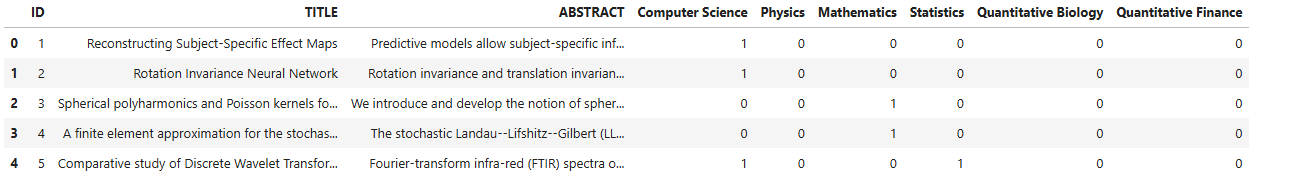

## Zero-shot başlangıç seviyesi

Few-shot'a geçmeden önce bir **zero-shot baseline** oluşturacağız.  
Burada, Llama 3’ten her özeti yalnızca görev tanımı ve etiket açıklamalarını kullanarak sınıflandırmasını istiyoruz; yani modele **hiç örnek vermiyoruz**.

Bu bize bir referans noktası sağlar: daha sonra same görevde birkaç örnek eklediğimizde modelin ne kadar iyileştiğini kıyaslayabiliriz.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!sudo apt-get install zstd
!sudo apt-get install lspci
!sudo apt-get install lshw

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 2s (394 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122354 files and directories currently i

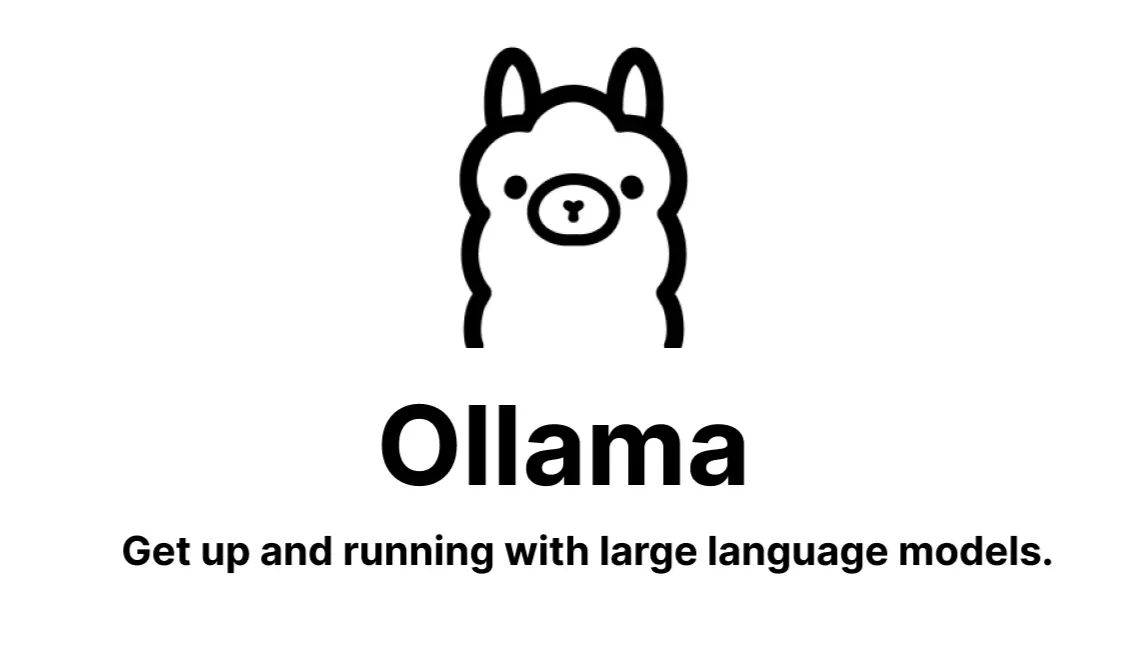

In [ ]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


🦙

In [ ]:
!nohup ollama serve > ollama.log 2>&1 &

In [ ]:
!ollama list

NAME    ID    SIZE    MODIFIED 


In [ ]:
!ollama pull llama3:8b

In [ ]:
!ollama list

NAME         ID              SIZE      MODIFIED      
llama3:8b    365c0bd3c000    4.7 GB    2 seconds ago    


In [ ]:
!pip install ollama

In [ ]:
import ollama
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
# Hızlı bir zero-shot baseline için küçük bir test verisi yüklüyoruz
df = pd.read_csv("/content/drive/MyDrive/text-classification-train.csv")
df_labeled = pd.DataFrame()
df_labeled["abstract"] = df["ABSTRACT"][:50]
df_labeled["actual_CS"] = df["Computer Science"][:50]
df_labeled.head()

,abstract,actual_CS
0,Predictive models allow subject-specific inf...,1
1,Rotation invariance and translation invarian...,1
2,We introduce and develop the notion of spher...,0
3,The stochastic Landau--Lifshitz--Gilbert (LL...,0
4,Fourier-transform infra-red (FTIR) spectra o...,1


### Zero-shot prompt

Zero-shot'ta model yalnızca şunları görür:
- görevin tanımını,
- etiketlerin anlamını,
- ve sınıflandırılacak yeni özeti.

Gördüğü şeyler arasında **etiketli örnekler yoktur**. Bu nedenle zero-shot sonucu, modelin bu göreve ne kadar “hazır” olduğunu gösterir.


In [ ]:
def create_zero_shot_prompt(abstract):
    prompt = f'''Task: Classify the following abstract as Computer Science (1) or non-Computer Science (0).
Please respond with only "1" or "0".

Abstract:
"{abstract}"

Classification:'''
    return prompt


def zero_shot_label_abstract(x):
    prompt = create_zero_shot_prompt(x)
    response = ollama.chat(model='llama3:8b', messages=[
      {
        'role': 'user',
        'content': prompt,
      },
    ])
    return response['message']['content']

### Zero-shot baseline’ı çalıştırma

Önce küçük bir alt küme üzerinde etiketleme yapıyoruz. Böylece çıktıları hızlıca inceleyebilir ve biraz sonra in-context sürümle rahatça karşılaştırabiliriz.


In [ ]:
df_labeled["Llama3_zero_shot_CS"] = 0

df_labeled.loc[:50, "Llama3_zero_shot_CS"] = df_labeled.loc[:50, "abstract"].apply(zero_shot_label_abstract)

df_labeled.head()

/tmp/ipykernel_1103/1402261596.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['1' '1' '1' '1' '1' '1' '0' '1' '1' '1' '1' '1' '0' '1' '0' '1' '0' '1'
 '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1'
 '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1' '1']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_labeled.loc[:50, "Llama3_zero_shot_CS"] = df_labeled.loc[:50, "abstract"].apply(zero_shot_label_abstract)


,abstract,actual_CS,Llama3_zero_shot_CS
0,Predictive models allow subject-specific inf...,1,1
1,Rotation invariance and translation invarian...,1,1
2,We introduce and develop the notion of spher...,0,1
3,The stochastic Landau--Lifshitz--Gilbert (LL...,0,1
4,Fourier-transform infra-red (FTIR) spectra o...,1,1


### Zero-shot baseline’ı değerlendirme

Bu kısım, in-context örnekleri eklemeden önce elde ettiğimiz başlangıç doğruluğunu verecek.


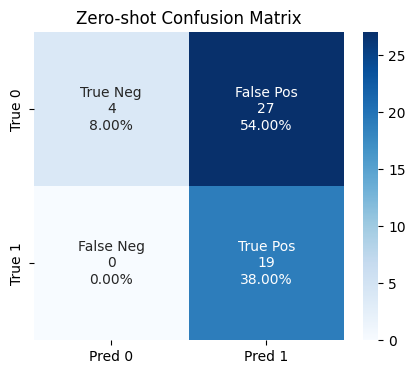

Accuracy : 0.46
Precision: 0.41304347826086957
Recall   : 1.0
F1 Score : 0.5846153846153846


In [ ]:
y_true_zero = df_labeled["actual_CS"].astype(str)
y_pred_zero = df_labeled["Llama3_zero_shot_CS"].astype(str).str.strip()

cm_zero = confusion_matrix(y_true_zero, y_pred_zero, labels=["0", "1"])
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm_zero.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm_zero.flatten()/np.sum(cm_zero)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
plt.figure(figsize=(5,4))
sns.heatmap(cm_zero, annot=labels, fmt="", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
plt.title("Zero-shot Confusion Matrix")
plt.show()

print("Accuracy :", accuracy_score(y_true_zero, y_pred_zero))
print("Precision:", precision_score(y_true_zero, y_pred_zero, pos_label="1"))
print("Recall   :", recall_score(y_true_zero, y_pred_zero, pos_label="1"))
print("F1 Score :", f1_score(y_true_zero, y_pred_zero, pos_label="1"))

Bu zero-shot sonucu bizim başlangıç noktamız.  
Şimdi **few-shot** adımına geçelim; burada prompt içine birkaç etiketli örnek koyup modelin daha güvenilir hale gelip gelmediğine bakacağız.


### Prompt’u oluşturma


```
Task: Classify each abstract as Computer Science (0) or non-Computer Science (1). Use the given examples as a guide.

Context: Computer Science abstracts often discuss subjects such as algorithms, machine learning, software development, computer systems, and data science. In contrast, non-CS abstracts address topics outside of these areas, like biology, statistics, physics, and finance.

Example 1:
Abstract: {abstract_1}
Classification: 1

Example 2:
Abstract: {abstract_2}
Classification: 0

Example 3:
Abstract: {abstract_3}
Classification: 1

Example 4:
Abstract: {abstract_4}
Classification: 0

Example 5:
Abstract: {abstract_5}
Classification: 0

Now, classify the following abstract:

Abstract: {abstract_6}
Classification:
```

Veri kümesindeki son dört öğeyi seçiyoruz; bunların üçü non-CS, biri ise CS tipi metin.

In [ ]:
def create_prompt(abstract):
    prompt = f'''Task: Classify each abstract as Computer Science (1) or non-Computer Science (0). Please only respond "1" or "0". Use the given examples as a guide.

Context: Computer Science abstracts often discuss subjects such as algorithms, machine learning, software development, computer systems, and data science. In contrast, non-CS abstracts address topics outside of these areas, like biology, statistics, physics, and finance.

Example 1:
Abstract: "We present numerical evidence that most two-dimensional surface states of a bulk topological superconductor (TSC) sit at an integer quantum Hall plateau transition. We study TSC surface states in class CI with quenched disorder. Low-energy (finite-energy) surface states were expected to be critically delocalized (Anderson localized). We confirm the low-energy picture, but find instead that finite-energy states are also delocalized, with universal statistics that are independent of the TSC winding number, and consistent with the spin quantum Hall plateau transition (percolation)."
Classification: non-CS

Example 2:
Abstract: "In this paper, we propose a new algorithm based on radial symmetry center method to track colloidal particles close to contact, where the optical images of the particles start to overlap in digital video microscopy. This overlapping effect is important to observe the pair interaction potential in colloidal studies and it appears as additional interaction in the measurement of the interaction with conventional tracking analysis. The proposed algorithm in this work is simple, fast and applicable for not only two particles but also three and more particles without any modification. The algorithm uses gradient vectors of the particle intensity distribution, which allows us to use a part of the symmetric intensity distribution in the calculation of the actual particle position. In this study, simulations are performed to see the performance of the proposed algorithm for two and three particles, where the simulation images are generated by using fitted curve to experimental particle image for different sized particles. As a result, the algorithm yields the maximum error smaller than 2 nm for 5.53 mu silica particles in contact condition."
Classification: non-CS

Example 3:
Abstract: "Queueing networks are systems of theoretical interest that give rise to complex families of stochastic processes, and find widespread use in the performance evaluation of interconnected resources. Yet, despite their importance within applications, and in comparison to their counterpart stochastic models in genetics or mathematical biology, there exist few relevant approaches for transient inference and uncertainty quantification tasks in these systems. This is a consequence of strong computational impediments and distinctive properties of the Markov jump processes induced by queueing networks. In this paper, we offer a comprehensive overview of the inferential challenge and its comparison to analogue tasks within related mathematical domains. We then discuss a model augmentation over an approximating network system, and present a flexible and scalable variational Bayesian framework, which is targeted at general-form open and closed queueing systems, with varied service disciplines and priorities. The inferential procedure is finally validated in a couple of uncertainty quantification tasks for network service rates."
Classification: CS

Example 4:
Abstract: "We construct Hall algebra of elliptic curve over $\\mathbb F_1$ using the theory of monoidal scheme due to Deitmar and the theory of Hall algebra for monoidal representations due to Szczesny. The resulting algebra is shown to be a specialization of elliptic Hall algebra studied by Burban and Schiffmann. Thus our algebra is isomorphic to the skein algebra for torus by the recent work of Morton and Samuelson."
Classification: non-CS

Now, classify the following abstract:

Abstract: {abstract}
Classification: '''
    return prompt

Ardından, Llama 3 kullanan bir etiketleme fonksiyonu tanımlıyoruz:


In [ ]:
def label_abstract(x):
    prompt = create_prompt(x)
    response = ollama.chat(model='llama3:8b', messages=[
      {
        'role': 'user',
        'content': prompt,
      },
    ])
    return response['message']['content']

In [ ]:
df_labeled["Llama3_ic_CS"] = 0

In [ ]:
df_labeled['Llama3_ic_CS'][:50] = df_labeled['abstract'][:50].apply(label_abstract)

/tmp/ipykernel_1103/3336229149.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_labeled['Llama3_ic_CS'][:50] = df_labeled['abstract'][:50].apply(label_abstract)
/tmp/ipykernel_1103/3336229149.py:1: SettingWithCopyWarning: 
A value is t

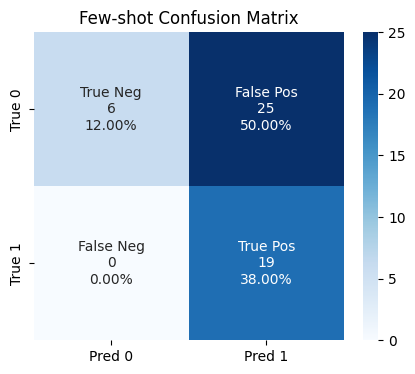

Accuracy : 0.5
Precision: 0.4318181818181818
Recall   : 1.0
F1 Score : 0.6031746031746031


In [ ]:
y_true = df_labeled["actual_CS"].astype(str)
y_pred = df_labeled["Llama3_ic_CS"].astype(str).str.strip()

cm = confusion_matrix(y_true, y_pred, labels=["0", "1"])
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
plt.title("Few-shot Confusion Matrix")
plt.show()

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, pos_label="1"))
print("Recall   :", recall_score(y_true, y_pred, pos_label="1"))
print("F1 Score :", f1_score(y_true, y_pred, pos_label="1"))

### Prompt’u iyileştirme
F1-score'da artış olsa da model hala tutarlı biçimde yanlış cevaplar üretiyor. 50 makalelik bir örneklemde doğruluk yaklaşık %60 gibi oldukça düşük bir seviyede kalıyor.

**CoT eklesek nasıl olurdu?** 🤔

Prompt’u daha dikkatli hale getiriyoruz: örneklere kısa gerekçeler ekliyoruz ve modele yalnızca **çok emin olduğunda** “CS” demesini açıkça söylüyoruz.

```
Task: Classify each abstract as Computer Science (CS) or non-Computer Science (non-CS). Please only respond "CS" if you are *very* confident that it is a CS abstract; otherwise, respond "non-CS". Use the given examples as a guide.

Context: Computer Science abstracts often discuss subjects such as algorithms, machine learning, software development, computer systems, and data science. In contrast, non-CS abstracts address topics outside of these areas, like biology, statistics, physics, and finance.

Example 1:
Abstract: "We present numerical evidence that most two-dimensional surface states of a bulk topological superconductor (TSC) sit at an integer quantum Hall plateau transition. We study TSC surface states in class CI with quenched disorder. Low-energy (finite-energy) surface states were expected to be critically delocalized (Anderson localized). We confirm the low-energy picture, but find instead that finite-energy states are also delocalized, with universal statistics that are independent of the TSC winding number, and consistent with the spin quantum Hall plateau transition (percolation)."
Classification: non-CS
Reason: The subject is physics, not computer science.

Example 2:
Abstract: "Polycrystalline diamond coatings have been grown on cemented carbide substrates with different aspect ratios by a microwave plasma CVD in methane-hydrogen gas mixtures. To protect the edges of the substrates from non-uniform heating due to the plasma edge effect, a special plateholder with pockets for group growth has been used. The difference in heights of the substrates and plateholder, and its influence on the diamond film mean grain size, growth rate, phase composition and stress was investigated. The substrate temperature range, within which uniform diamond films are produced with good adhesion, is determined. The diamond-coated cutting inserts produced at optimized process exhibited a reduction of cutting force and wear resistance by a factor of two, and cutting efficiency increase by 4.3 times upon turning A390 Al-Si alloy as compared to performance of uncoated tools."
Classification: non-CS
Reason: The subject is physics, not computer science.

Example 3:
Abstract: "Machine learning is finding increasingly broad application in the physical sciences. This most often involves building a model relationship between a dependent, measurable output and an associated set of controllable, but complicated, independent inputs. We present a tutorial on current techniques in machine learning -- a jumping-off point for interested researchers to advance their work. We focus on deep neural networks with an emphasis on demystifying deep learning. We begin with background ideas in machine learning and some example applications from current research in plasma physics. We discuss supervised learning techniques for modeling complicated functions, beginning with familiar regression schemes, then advancing to more sophisticated deep learning methods. We also address unsupervised learning and techniques for reducing the dimensionality of input spaces. Along the way, we describe methods for practitioners to help ensure that their models generalize from their training data to as-yet-unseen test data.",
Classification: CS
Reason: The abstract discusses machine learning, which is a computer science concept.  

Example 4:
Abstract: "We construct Hall algebra of elliptic curve over $\\mathbb F_1$ using the theory of monoidal scheme due to Deitmar and the theory of Hall algebra for monoidal representations due to Szczesny. The resulting algebra is shown to be a specialization of elliptic Hall algebra studied by Burban and Schiffmann. Thus our algebra is isomorphic to the skein algebra for torus by the recent work of Morton and Samuelson."
Classification: non-CS
Reason: The subject is mathematics, not computer science.

Now, classify the following abstract:

Abstract: {abstract}
Classification:
```

In [ ]:
def create_prompt(abstract):
    prompt = f'''Task: Classify each abstract as Computer Science (CS) or non-Computer Science (non-CS). Please only respond "CS" if you are *very* confident that it is a CS abstract; otherwise, respond "non-CS". Use the given examples as a guide.

Context: Computer Science abstracts often discuss subjects such as algorithms, machine learning, software development, computer systems, and data science. In contrast, non-CS abstracts address topics outside of these areas, like biology, statistics, physics, and finance.

Example 1:
Abstract: "We present numerical evidence that most two-dimensional surface states of a bulk topological superconductor (TSC) sit at an integer quantum Hall plateau transition. We study TSC surface states in class CI with quenched disorder. Low-energy (finite-energy) surface states were expected to be critically delocalized (Anderson localized). We confirm the low-energy picture, but find instead that finite-energy states are also delocalized, with universal statistics that are independent of the TSC winding number, and consistent with the spin quantum Hall plateau transition (percolation)."
Classification: non-CS
Reason: The subject is physics, not computer science.

Example 2:
Abstract: "Polycrystalline diamond coatings have been grown on cemented carbide substrates with different aspect ratios by a microwave plasma CVD in methane-hydrogen gas mixtures. To protect the edges of the substrates from non-uniform heating due to the plasma edge effect, a special plateholder with pockets for group growth has been used. The difference in heights of the substrates and plateholder, and its influence on the diamond film mean grain size, growth rate, phase composition and stress was investigated. The substrate temperature range, within which uniform diamond films are produced with good adhesion, is determined. The diamond-coated cutting inserts produced at optimized process exhibited a reduction of cutting force and wear resistance by a factor of two, and cutting efficiency increase by 4.3 times upon turning A390 Al-Si alloy as compared to performance of uncoated tools."
Classification: non-CS
Reason: The subject is physics, not computer science.

Example 3:
Abstract: "Machine learning is finding increasingly broad application in the physical sciences. This most often involves building a model relationship between a dependent, measurable output and an associated set of controllable, but complicated, independent inputs. We present a tutorial on current techniques in machine learning -- a jumping-off point for interested researchers to advance their work. We focus on deep neural networks with an emphasis on demystifying deep learning. We begin with background ideas in machine learning and some example applications from current research in plasma physics. We discuss supervised learning techniques for modeling complicated functions, beginning with familiar regression schemes, then advancing to more sophisticated deep learning methods. We also address unsupervised learning and techniques for reducing the dimensionality of input spaces. Along the way, we describe methods for practitioners to help ensure that their models generalize from their training data to as-yet-unseen test data.",
Classification: CS
Reason: The abstract discusses machine learning, which is a computer science concept.

Example 4:
Abstract: "We construct Hall algebra of elliptic curve over $\\mathbb F_1$ using the theory of monoidal scheme due to Deitmar and the theory of Hall algebra for monoidal representations due to Szczesny. The resulting algebra is shown to be a specialization of elliptic Hall algebra studied by Burban and Schiffmann. Thus our algebra is isomorphic to the skein algebra for torus by the recent work of Morton and Samuelson."
Classification: non-CS
Reason: The subject is mathematics, not computer science; abstracts must explicitly discuss computer science topics, even if the math discussed could be applicable to computer science.

Now, classify the following abstract:

Abstract: {abstract}
Classification: '''
    return prompt

In [ ]:
def label_abstract(x):
    prompt = create_prompt(x)
    response = ollama.chat(model='llama3:8b', messages=[
      {
        'role': 'user',
        'content': prompt,
      },
    ])
    print(response['message']['content'])
    if 'non-CS' in response['message']['content'][:10]: # Restrict to only beginning
        return 0
    return 1

In [ ]:
df_labeled['Llama3_ic2_CS'] = 0

In [ ]:
df_labeled['Llama3_ic2_CS'][:50] = df_labeled['abstract'][:50].apply(label_abstract)

I would classify this abstract as CS.

Reason: The abstract discusses machine learning, predictive modeling, and algorithmic approaches to improve subject-specific detections in neuroimaging data. It also mentions binary classifiers, Maximum-A-Posteriori problems, and wrapper-type algorithms, which are all computer science concepts.
CS

Reason: The abstract discusses a computer science concept (convolutional neural networks and one-shot learning) and mentions specific topics like rotation and translation invariance, which are relevant to computer vision and machine learning.
non-CS

Reason: The subject is mathematics, specifically harmonic analysis and special functions, which are not computer science topics. While the concepts discussed may have applications in computer science (e.g., signal processing), the abstract does not explicitly discuss computer science topics or methods.
non-CS

Reason: The subject is physics and mathematics, not computer science; while it mentions numerical 

/tmp/ipykernel_1103/1880000339.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_labeled['Llama3_ic2_CS'][:50] = df_labeled['abstract'][:50].apply(label_abstract)
/tmp/ipykernel_1103/1880000339.py:1: SettingWithCopyWarning: 
A value is 

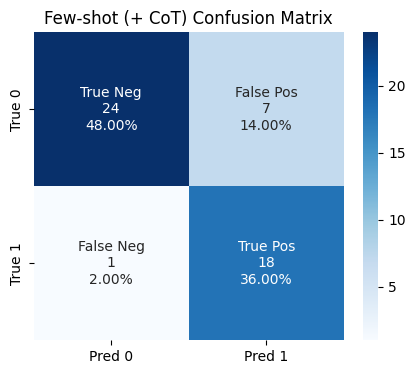

Accuracy : 0.84
Precision: 0.72
Recall   : 0.9473684210526315
F1 Score : 0.8181818181818182


In [ ]:
y_true = df_labeled["actual_CS"].astype(str)
y_pred = df_labeled["Llama3_ic2_CS"].astype(str).str.strip()

cm = confusion_matrix(y_true, y_pred, labels=["0", "1"])
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
plt.title("Few-shot (+ CoT) Confusion Matrix")
plt.show()

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, pos_label="1"))
print("Recall   :", recall_score(y_true, y_pred, pos_label="1"))
print("F1 Score :", f1_score(y_true, y_pred, pos_label="1"))

Performans artmış gibi görünüyor.
# CoT gerçekten işe yarıyor mu? ⛓ 📈

In [ ]:
df_labeled[:25]

,abstract,actual_CS,Llama3_zero_shot_CS,Llama3_ic_CS,Llama3_ic2_CS
0,Predictive models allow subject-specific inf...,1,1,1,1
1,Rotation invariance and translation invarian...,1,1,1,1
2,We introduce and develop the notion of spher...,0,1,1,0
3,The stochastic Landau--Lifshitz--Gilbert (LL...,0,1,1,0
4,Fourier-transform infra-red (FTIR) spectra o...,1,1,1,1
5,Let $\Omega \subset \mathbb{R}^n$ be a bound...,0,1,1,0
6,We observed the newly discovered hyperbolic ...,0,0,0,0
7,The ability of metallic nanoparticles to sup...,0,1,1,0
8,We model large-scale ($\approx$2000km) impac...,0,1,1,0
9,Time varying susceptibility of host at indiv...,0,1,1,0


Bu prompting yöntemş çok daha iyi iş çıkardı. Özellikle metni CS olarak etiketleme konusunda daha temkinli davranıyor ve daha sık 0’a, yani non-CS sınıfına dönüyor. Şimdi yanlış sınıflandırdığı örneklere bakalım:


In [ ]:
df_labeled.loc[18]["abstract"]

'  When investigators seek to estimate causal effects, they often assume that\nselection into treatment is based only on observed covariates. Under this\nidentification strategy, analysts must adjust for observed confounders. While\nbasic regression models have long been the dominant method of statistical\nadjustment, more robust methods based on matching or weighting have become more\ncommon. Of late, even more flexible methods based on machine learning methods\nhave been developed for statistical adjustment. These machine learning methods\nare designed to be black box methods with little input from the researcher.\nRecent research used a data competition to evaluate various methods of\nstatistical adjustment and found that black box methods out performed all other\nmethods of statistical adjustment. Matching methods with covariate\nprioritization are designed for direct input from substantive investigators in\ndirect contrast to black methods. In this article, we use a different rese

Makine öğrenmesi ile ilgili birçok teknik, bilgisayar biliminden ziyade istatistik altında da yorumlanabilir; dolayısıyla bu hata anlaşılır görünüyor. Açıkçası bu örnek istatistiğe bilgisayar biliminden daha yakın duruyor.

> Reason: The abstract discusses machine learning techniques and performance metrics, which are related to statistics and data analysis rather than core computer science topics. Therefore, it is more likely a non-CS abstract.


In [ ]:
df_labeled.loc[13]["abstract"]

'  The classical Eilenberg correspondence, based on the concept of the syntactic\nmonoid, relates varieties of regular languages with pseudovarieties of finite\nmonoids. Various modifications of this correspondence appeared, with more\ngeneral classes of regular languages on one hand and classes of more complex\nalgebraic structures on the other hand. For example, classes of languages need\nnot be closed under complementation or all preimages under homomorphisms, while\nmonoids can be equipped with a compatible order or they can have a\ndistinguished set of generators. Such generalized varieties and pseudovarieties\nalso have natural counterparts formed by classes of finite (ordered) automata.\nIn this paper the previous approaches are combined. The notion of positive\n$\\mathcal C$-varieties of ordered semiautomata (i.e. no initial and final\nstates are specified) is introduced and their correspondence with positive\n$\\mathcal C$-varieties of languages is proved.\n'

Prompt içindeki tek CS örneği yoğun biçimde makine öğrenmesi odaklı. Belki de bu yüzden model, aslında CS olan ama daha teorik duran bu araştırma makalesini CS olarak görmüyor.

> Reason: The subject is mathematics, specifically the study of algebraic structures and regular languages, which is not a computer science topic. Although regular languages are used in computer science, the abstract focuses on mathematical properties rather than computer science applications.


In [ ]:
df_labeled.loc[10]["abstract"]

'  We present a systematic global sensitivity analysis using the Sobol method\nwhich can be utilized to rank the variables that affect two quantity of\ninterests -- pore pressure depletion and stress change -- around a\nhydraulically-fractured horizontal well based on their degree of importance.\nThese variables include rock properties and stimulation design variables. A\nfully-coupled poroelastic hydraulic fracture model is used to account for pore\npressure and stress changes due to production. To ease the computational cost\nof a simulator, we also provide reduced order models (ROMs), which can be used\nto replace the complex numerical model with a rather simple analytical model,\nfor calculating the pore pressure and stresses at different locations around\nhydraulic fractures. The main findings of this research are: (i) mobility,\nproduction pressure, and fracture half-length are the main contributors to the\nchanges in the quantities of interest. The percentage of the contribution

Bunu bir CS örneği olarak sınıflandırmak oldukça zor. Görünüşe göre model de benzer şekilde düşünmüş:

> Reason: The subject is physics/statistics, specifically related to hydraulic fracturing, poroelastic models, and sensitivity analysis. While these topics may involve computational simulations, they do not explicitly fall under computer science.


### In-context learning ile Llama 3’ü değerlendirme


Oldukça etkileyici! Bu sonuç bize şunu gösteriyor: modelin ağırlıklarına dokunmadan, yalnızca prompt’u ve örnekleri değiştirerek kayda değer bir iyileşme elde edebiliyoruz. Bu, in-context learning’in pratik gücünü çok iyi gösteren bir nokta.


## Reflexion adımı ekleme

CoT prompting modeli ciddi biçimde iyileştirdi; fakat bir adım daha ileri gidebiliriz: modelden son etiketi vermeden önce **ilk kararını gözden geçirmesini** isteyebiliriz.

Bu, **Reflexion**’ın hafif bir biçimi olarak düşünülebilir. Model önce ilk yargısını verir, sonra kendi gerekçesini kısaca kontrol eder ve son kararı buna göre üretir. Böylece özellikle sınırda kalan örneklerde biraz daha dikkatli davranmasını umarız.


In [ ]:
def create_reflexion_prompt(abstract):
    prompt = f'''Task: Classify the following abstract as Computer Science (CS) or non-Computer Science (non-CS).

You must use this two-step process:
Step 1 - Initial decision: briefly state whether the abstract looks CS or non-CS.
Step 2 - Self-review: check your first decision carefully. Only keep "CS" if there is strong evidence of core computer science topics such as algorithms, machine learning, computer vision, natural language processing, software systems, databases, operating systems, networking, security, robotics, programming languages, or theoretical computer science. If the abstract is mainly about biology, physics, finance, mathematics, or statistics, the final answer should be "non-CS".

Use the following examples as a guide.

Example 1:
Abstract: "We present numerical evidence that most two-dimensional surface states of a bulk topological superconductor (TSC) sit at an integer quantum Hall plateau transition. We study TSC surface states in class CI with quenched disorder. Low-energy (finite-energy) surface states were expected to be critically delocalized (Anderson localized). We confirm the low-energy picture, but find instead that finite-energy states are also delocalized, with universal statistics that are independent of the TSC winding number, and consistent with the spin quantum Hall plateau transition (percolation)."
Initial decision: non-CS
Self-review: This is clearly about condensed matter physics and superconductors, not computer science.
Final classification: non-CS

Example 2:
Abstract: "Polycrystalline diamond coatings have been grown on cemented carbide substrates with different aspect ratios by a microwave plasma CVD in methane-hydrogen gas mixtures. To protect the edges of the substrates from non-uniform heating due to the plasma edge effect, a special plateholder with pockets for group growth has been used. The difference in heights of the substrates and plateholder, and its influence on the diamond film mean grain size, growth rate, phase composition and stress was investigated. The substrate temperature range, within which uniform diamond films are produced with good adhesion, is determined. The diamond-coated cutting inserts produced at optimized process exhibited a reduction of cutting force and wear resistance in the machining of a SiAlON ceramic."
Initial decision: non-CS
Self-review: This is materials engineering and manufacturing, not computer science.
Final classification: non-CS

Example 3:
Abstract: "Deep neural networks are increasingly used for image segmentation and object recognition. We propose a new training method that improves convergence speed while preserving predictive accuracy across several benchmark datasets."
Initial decision: CS
Self-review: The abstract is explicitly about deep neural networks, image segmentation, and benchmark datasets, which are strong computer science signals.
Final classification: CS

Now classify this abstract.

Abstract: "{abstract}"

Respond in exactly this format:
Initial decision: <CS or non-CS>
Self-review: <one short sentence>
Final classification: <CS or non-CS>'''
    return prompt


def label_abstract_reflexion(x):
    prompt = create_reflexion_prompt(x)
    response = ollama.chat(model='llama3:8b', messages=[
      {
        'role': 'user',
        'content': prompt,
      },
    ])
    content = response['message']['content']
    print(content)

    # Prefer the final reviewed answer if it is present
    final_match = re.search(r'Final classification:\s*(CS|non-CS)', content, flags=re.IGNORECASE)
    if final_match:
        label = final_match.group(1).lower()
        return 0 if label == 'non-cs' else 1

    # Fallback: inspect the beginning conservatively
    if 'non-CS' in content[:30] or 'non-cs' in content[:30]:
        return 0
    return 1

Önce Reflexion’ı ilk 50 özet üzerinde test edelim. Self-review adımının modeli daha temkinli yapıp yapmadığını ve precision’ı artırıp artırmadığını görmek istiyoruz.


In [ ]:
df_reflexion = df_labeled.iloc[:50].copy()
df_reflexion['Llama3_reflexion_CS'] = 0
df_reflexion['Llama3_reflexion_CS'] = df_reflexion['abstract'].apply(label_abstract_reflexion)
df_reflexion.head()

Initial decision: CS
Self-review: This abstract appears to be about machine learning and image analysis, with topics like predictive modeling, binary classifiers, and data reconstruction.
Final classification: CS
Initial decision: CS
Self-review: The abstract discusses a new architecture in convolutional neural networks (CNNs) for achieving rotation and translation invariance, which are core computer science topics.
Final classification: CS
Initial decision: non-CS
Self-review: The abstract appears to be about mathematics and harmonic analysis, with no strong computer science signals.
Final classification: non-CS
Initial decision: CS
Self-review: The abstract discusses numerical methods and stochastic equations, which are related to computer science topics such as algorithms and theoretical computer science.
Final classification: CS
Initial decision: CS
Self-review: The abstract uses machine learning algorithms and features computer science techniques such as preprocessing, feature ext

,abstract,actual_CS,Llama3_zero_shot_CS,Llama3_ic_CS,Llama3_ic2_CS,Llama3_reflexion_CS
0,Predictive models allow subject-specific inf...,1,1,1,1,1
1,Rotation invariance and translation invarian...,1,1,1,1,1
2,We introduce and develop the notion of spher...,0,1,1,0,0
3,The stochastic Landau--Lifshitz--Gilbert (LL...,0,1,1,0,1
4,Fourier-transform infra-red (FTIR) spectra o...,1,1,1,1,1


### Reflexion değerlendirme


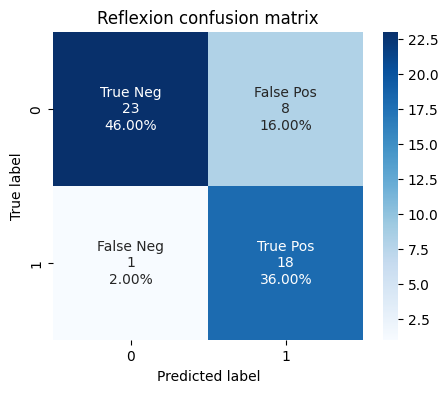

Accuracy:  0.820
Precision: 0.692
Recall:    0.947
F1 score:  0.800


In [ ]:
cm_ref = confusion_matrix(df_reflexion['actual_CS'], df_reflexion['Llama3_reflexion_CS'])

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cm_ref.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm_ref.flatten()/np.sum(cm_ref)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(5,4))
sns.heatmap(cm_ref, annot=labels, fmt="", cmap='Blues')
plt.title("Reflexion confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

acc_ref = accuracy_score(df_reflexion['actual_CS'], df_reflexion['Llama3_reflexion_CS'])
prec_ref = precision_score(df_reflexion['actual_CS'], df_reflexion['Llama3_reflexion_CS'])
rec_ref = recall_score(df_reflexion['actual_CS'], df_reflexion['Llama3_reflexion_CS'])
f1_ref = f1_score(df_reflexion['actual_CS'], df_reflexion['Llama3_reflexion_CS'])

print(f"Accuracy:  {acc_ref:.3f}")
print(f"Precision: {prec_ref:.3f}")
print(f"Recall:    {rec_ref:.3f}")
print(f"F1 score:  {f1_ref:.3f}")

**Reflexion, Recall'u iyileştirse de genel performansta çok büyük bir sıçrama meydana getirmemiş gibi duruyor.**

Reflexion, daha dikkatli ve daha güvenilir kararlar verebilir; fakat karşılığında daha uzun prompt’lar ve daha yavaş çıkarım süresi getirebilir. Yani kalite ile maliyet / gecikme arasında bir trade-off söz konusudur. ⏰


# Daha iyi performans istiyorum... ▶ (Instruction) Supervised Finetuning (SFT) 🦾 🖥

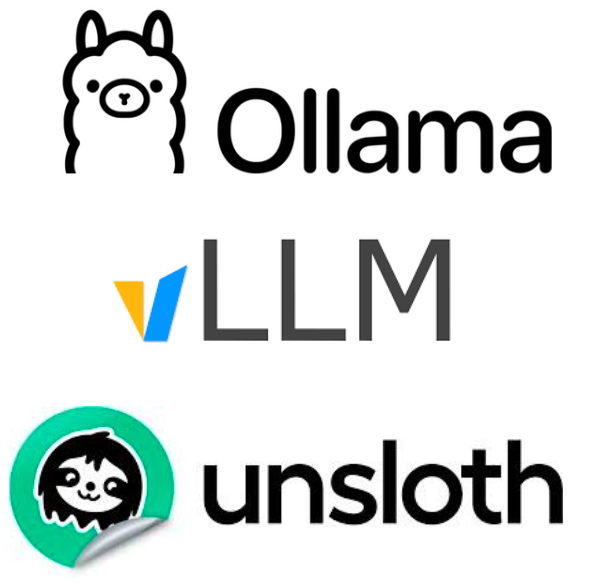

In [ ]:
!pip install trl
!pip install trackio
!pip install -U bitsandbytes>=0.46.1
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 55.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.14.0
    Uninstalling gradio_client-1.14.0:
      Successfully uninstalled gradio_client-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are instal

text-classification-train.csv dataset dosyasını Drive'ımıza yükleyelim ve Colab oturumumuzu Drive'a bağlayalım

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Dataseti LLama'nın anlayabileceği "Conversational Prompt-completion" formatına getirelim. (bkz: Huggingface Datasets)

In [ ]:
import pandas as pd
import json
from sklearn.model_selection import train_test_split


csv_path = "/content/drive/MyDrive/text-classification-train.csv"

train_output_path = "/content/sft_train.jsonl"
test_output_path = "/content/sft_test.jsonl"


df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# basic checks
required_columns = ["ABSTRACT", "Computer Science"]

for column in required_columns:
    if column not in df.columns:
        raise ValueError(f"Missing required column: {column}")


# clean data
df = df.dropna(subset=["ABSTRACT", "Computer Science"])

df["ABSTRACT"] = df["ABSTRACT"].astype(str)
df["Computer Science"] = df["Computer Science"].astype(int)


# convert labels
def convert_label(cs_value):
    if cs_value == 1:
        return "CS"
    else:
        return "non-CS"


df["label"] = df["Computer Science"].apply(convert_label)


print("\nLabel distribution:")
print(df["label"].value_counts())


# create SFT sample
system_prompt = (
    "You are an academic abstract classifier. "
    "Classify abstracts as CS or non-CS. "
    "Answer only with CS or non-CS."
)


def create_sft_example(abstract, label):
    user_prompt = (
        "Classify the following abstract as CS or non-CS:\n\n"
        f"{abstract}"
    )

    example = {
        "messages": [
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": user_prompt
            },
            {
                "role": "assistant",
                "content": label
            }
        ]
    }

    return example


examples = []

for _, row in df.iterrows():
    abstract = row["ABSTRACT"]
    label = row["label"]

    example = create_sft_example(abstract, label)
    examples.append(example)


print("\nNumber of SFT examples:", len(examples))


# train-test split
train_examples, test_examples = train_test_split(
    examples,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)


print("Train examples:", len(train_examples))
print("Test examples:", len(test_examples))


def save_jsonl(data, output_path):
    with open(output_path, "w", encoding="utf-8") as f:
        for item in data:
            json_line = json.dumps(item, ensure_ascii=False)
            f.write(json_line + "\n")


save_jsonl(train_examples, train_output_path)
save_jsonl(test_examples, test_output_path)

print("\nSaved files:")
print(train_output_path)
print(test_output_path)

Dataset shape: (20972, 9)
Columns:
['ID', 'TITLE', 'ABSTRACT', 'Computer Science', 'Physics', 'Mathematics', 'Statistics', 'Quantitative Biology', 'Quantitative Finance']

Label distribution:
label
non-CS    12378
CS         8594
Name: count, dtype: int64

Number of SFT examples: 20972
Train examples: 16777
Test examples: 4195

Saved files:
/content/sft_train.jsonl
/content/sft_test.jsonl


In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

In [ ]:
train_dataset = load_dataset("json", data_files="/content/sft_train.jsonl", split="train")
test_dataset = load_dataset("json", data_files="/content/sft_test.jsonl", split="train")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['messages'],
    num_rows: 16777
})

In [ ]:
train_dataset[0]

{'messages': [{'role': 'system',
   'content': 'You are an academic abstract classifier. Classify abstracts as CS or non-CS. Answer only with CS or non-CS.'},
  {'role': 'user',
   'content': 'Classify the following abstract as CS or non-CS:\n\n  The algorithmic Markov condition states that the most likely causal direction\nbetween two random variables X and Y can be identified as that direction with\nthe lowest Kolmogorov complexity. Due to the halting problem, however, this\nnotion is not computable.\nWe hence propose to do causal inference by stochastic complexity. That is, we\npropose to approximate Kolmogorov complexity via the Minimum Description Length\n(MDL) principle, using a score that is mini-max optimal with regard to the\nmodel class under consideration. This means that even in an adversarial\nsetting, such as when the true distribution is not in this class, we still\nobtain the optimal encoding for the data relative to the class.\nWe instantiate this framework, which we c

In [ ]:
# Modelimizi seçiyoruz 👇
## Qwen
# model_id, output_dir = "unsloth/qwen3-14b-unsloth-bnb-4bit", "qwen3-14b-unsloth-bnb-4bit-SFT"     # ⚠️ ~14.1 GB VRAM
# model_id, output_dir = "Qwen/Qwen3-8B", "Qwen3-8B-SFT"                                          # ⚠️ ~12.8 GB VRAM
# model_id, output_dir = "Qwen/Qwen2.5-7B-Instruct", "Qwen2.5-7B-Instruct"                        # ✅ ~10.8 GB VRAM
# model_id, output_dir = "Qwen/Qwen2.5-0.5B-Instruct", "05prey/Qwen2.5-0.5B-Instruct"

## Llama
# model_id, output_dir = "meta-llama/Llama-3.2-3B-Instruct", "Llama-3.2-3B-Instruct"              # ✅ ~4.7 GB VRAM
# model_id, output_dir = "meta-llama/Llama-3.1-8B-Instruct", "Llama-3.1-8B-Instruct"              # ⚠️ ~10.9 GB VRAM
# NOT: Llama'yı kullanabilmek için Huggingface(HF) hesabınızla Meta'nın HF reposunda izin istemelisiniz. İzin genelde birkaç saat içinde veriliyor.
# Llama üstünden gitmeye çalışalım ama izin almada sorun yaşarsanız modeli Qwen/Qwen2.5-0.5B-Instruct ile değiştirebilirisiniz
model_id, output_dir = "meta-llama/Meta-Llama-3-8B-Instruct", "05prey/Meta-Llama-3-8B-Instruct"

## Gemma
# model_id, output_dir = "google/gemma-3n-E2B-it", "gemma-3n-E2B-it"                              # ❌ Upgrade to a higher tier of colab
# model_id, output_dir = "google/gemma-3-4b-it", "gemma-3-4b-it"                                  # ⚠️ ~6.8 GB VRAM

## Granite
#model_id, output_dir = "ibm-granite/granite-4.0-micro", "granite-4.0-micro"                      # ✅ ~3.3 GB VRAM

## LFM2
#model_id, output_dir = "LiquidAI/LFM2-2.6B", "LFM2-2.6B-SFT"                                     # ✅ ~5.89 GB VRAM

In [ ]:
from huggingface_hub import login
login()

In [ ]:
from huggingface_hub import logout, login

logout()
login(token="BU KISMA HUGGINGFACE TOKEN'IMIZI KOYUYORUZ")
# token alıren token'a "read" yetkileri vermelisiniz

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Not logged in!


In [ ]:
# Quantization ayarlarını yapıp Llama modelimizi instantiate edelim
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    attn_implementation="sdpa",                   # Change to Flash Attention if GPU has support
    dtype=torch.float16,                          # Change to bfloat16 if GPU has support
    use_cache=True,                              # Whether to cache attention outputs to speed up inference
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,                        # Load the model in 4-bit precision to save memory
        bnb_4bit_compute_dtype=torch.float16,     # Data type used for internal computations in quantization
        bnb_4bit_use_double_quant=True,           # Use double quantization to improve accuracy
        bnb_4bit_quant_type="nf4"                 # Type of quantization. "nf4" is recommended for recent LLMs
    ),
    # trust_remote_code=True
)

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [ ]:
# LoRA ayarları
from peft import LoraConfig

# You may need to update `target_modules` depending on the architecture of your chosen model.
# For example, different LLMs might have different attention/projection layer names.
peft_config = LoraConfig(
    r=128,
    lora_alpha=384, # 256/128=2 ölçeğiyle etki edecek
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj",],
)

In [ ]:
# Eğitim ayarları
from trl import SFTConfig

training_args = SFTConfig(
    # Training schedule / optimization
    per_device_train_batch_size = 1,      # Batch size per GPU
    gradient_accumulation_steps = 4,      # Gradients are accumulated over multiple steps → effective batch size = 2 * 8 = 16
    warmup_steps = 5,
    # num_train_epochs = 1,               # Number of full dataset passes. For shorter training, use `max_steps` instead (this case)
    max_steps = 30,
    learning_rate = 2e-5,                 # Learning rate for the optimizer
    optim = "paged_adamw_8bit",           # Optimizer

    # Logging / reporting
    logging_steps=1,                      # Log training metrics every N steps
    report_to="trackio",                  # Experiment tracking tool
    trackio_space_id=output_dir,          # HF Space where the experiment tracking will be saved
    output_dir=output_dir,                # Where to save model checkpoints and logs

    max_length=1024,                      # Maximum input sequence length
    use_liger_kernel=False,                # Enable Liger kernel optimizations for faster training
    activation_offloading=True,           # Offload activations to CPU to reduce GPU memory usage

    # Hub integration
    push_to_hub=False,                     # Automatically push the trained model to the Hugging Face Hub
                                          # The model will be saved under your Hub account in the repository named `output_dir`

)

In [ ]:
# modelimizi eğitecek olan SFT Trainer'ı instantiate edelim
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    peft_config=peft_config
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Tokenizing train dataset:   0%|          | 0/16777 [00:00<?, ? examples/s]

In [ ]:
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)

print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A100-SXM4-40GB. Max memory = 39.494 GB.
0.967 GB of memory reserved.


In [ ]:
# Eğitim Zamanı!!
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128009}.


* Trackio project initialized: huggingface
* Trackio metrics will be synced to Hugging Face Bucket: https://huggingface.co/buckets/05prey/Meta-Llama-3-8B-Instruct-bucket
* Creating new space: https://huggingface.co/spaces/05prey/Meta-Llama-3-8B-Instruct
* Attached bucket 05prey/Meta-Llama-3-8B-Instruct-bucket at '/data'
* Waiting for Space to be ready...


* NVIDIA GPU detected, enabling automatic GPU metrics logging
* Created new run: 05prey-1777450617


Step,Training Loss
1,2.855200
2,2.689650
3,2.807970
4,2.392310
5,2.212050
6,2.353275
7,2.051292
8,1.690108
9,1.607667
10,1.910904


* Run finished. Uploading logs to the remote Trackio server (please wait...)


Number of logged loss points: 30


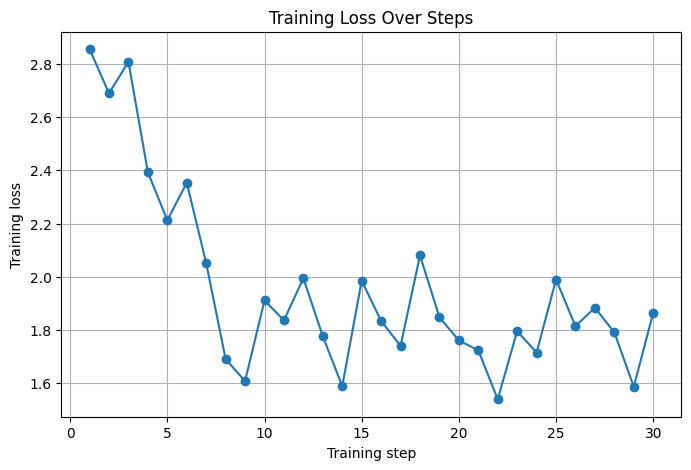

In [ ]:

import matplotlib.pyplot as plt

log_history = trainer.state.log_history

steps = []
losses = []

for log in log_history:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

print("Number of logged loss points:", len(losses))

plt.figure(figsize=(8, 5))
plt.plot(steps, losses, marker="o")
plt.xlabel("Training step")
plt.ylabel("Training loss")
plt.title("Training Loss Over Steps")
plt.grid(True)
plt.show()

In [ ]:
trainer.save_model(output_dir=output_dir)
# trainer.push_to_hub(dataset_name=dataset_name)

Trackio'da sonuçları görebilmek için, oluşturduğnuz HF token'ınıza "write" yetkisi de vermelisiniz

In [ ]:
messages = [{"role": "system", "content": "You are an academic abstract classifier. Classify abstracts as CS or non-CS. Answer only with CS or non-CS."}, {"role": "user", "content": "Classify the following abstract as CS or non-CS:\n\n  We develope a self-consistent description of the Broad Line Region based on\nthe concept of the failed wind powered by the radiation pressure acting on\ndusty accretion disk atmosphere in Keplerian motion. The material raised high\nabove the disk is illuminated, dust evaportes, and the matter falls back\ntowards the disk. This material is the source of emission lines. The model\npredicts the inner and outer radius of the region, the cloud dynamics under the\ndust radiation pressure and, subsequently, just the gravitational field of the\ncentral black hole, which results in assymetry between the rise and fall.\nKnowledge of the dynamics allows to predict the shapes of the emission lines as\nfunctions of the basic parameters of an active nucleus: black hole mass,\naccretion rate, black hole spin (or accretion efficiency) and the viewing angle\nwith respect to the symmetry axis. Here we show preliminary results based on\nanalytical approximations to the cloud motion.\n"}]

In [ ]:
from peft import PeftModel, PeftConfig
# Adapter (LoRA) ağırlıklarının kaydedildiği dizin
adapter_model = output_dir
# Modelimizin çalışabilmesi hem base model (Llama-3-8b) hem de Adapter (LoRA ile fine ettiğimiz ağırlıklar) işbirliği içinde çalışmalı
fine_tuned_model = PeftModel.from_pretrained(base_model, adapter_model)

In [ ]:
# Örnek prediction
text = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=False
)
model_inputs = tokenizer([text], return_tensors="pt").to(fine_tuned_model.device)

generated_ids = fine_tuned_model.generate(
    **model_inputs,
    max_new_tokens=512
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):]

# Decode and extract model response
generated_text = tokenizer.decode(output_ids, skip_special_tokens=True)
print(generated_text)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


non-CS


In [ ]:
# Sistematik şekilde, eğittiğimiz modelimizn 50 doküman özeti üstünde sınıflandırma performansını test edelim
import re
import torch

def extract_true_label(example):
    for message in example["messages"]:
        if message["role"] == "assistant":
            return message["content"].strip()
    return None


def prepare_inference_messages(example):
    return [
        message for message in example["messages"]
        if message["role"] != "assistant"
    ]


def normalize_prediction(generated_text):
    text = generated_text.strip()

    # Only look at the first line / first short answer
    first_line = text.splitlines()[0].strip()

    # Important: check non-CS before CS
    if re.fullmatch(r"non[- ]?cs\.?", first_line, re.IGNORECASE):
        return "non-CS"

    if re.fullmatch(r"cs\.?", first_line, re.IGNORECASE):
        return "CS"

    # Fallback for slightly longer generations
    lower_text = first_line.lower()

    if lower_text.startswith("non-cs") or lower_text.startswith("non cs"):
        return "non-CS"

    if lower_text.startswith("cs"):
        return "CS"

    return "unknown"


def predict_one(example, model, tokenizer, max_new_tokens=5):
    messages = prepare_inference_messages(example)

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Decode only newly generated tokens
    new_tokens = generated_ids[0][inputs["input_ids"].shape[-1]:]
    generated_text = tokenizer.decode(new_tokens, skip_special_tokens=True)

    predicted_label = normalize_prediction(generated_text)

    return predicted_label, generated_text

In [ ]:
from tqdm import tqdm
num_test_samples = 50   # Use None for the full test set.

if num_test_samples is None:
    eval_dataset = test_dataset
else:
    eval_dataset = test_dataset.select(range(min(num_test_samples, len(test_dataset))))

results = []

for example in tqdm(eval_dataset):
    true_label = extract_true_label(example)
    predicted_label, raw_output = predict_one(example, fine_tuned_model, tokenizer)

    results.append({
        "true_label": true_label,
        "predicted_label": predicted_label,
        "raw_output": raw_output
    })

results_df = pd.DataFrame(results)
results_df.head()

100%|██████████| 50/50 [07:44<00:00,  9.28s/it]


,true_label,predicted_label,raw_output
0,non-CS,CS,CS
1,CS,non-CS,non-CS
2,non-CS,non-CS,non-CS
3,non-CS,CS,CS
4,non-CS,non-CS,non-CS



Classification Report:
              precision    recall  f1-score   support

          CS       0.76      0.84      0.80        19
      non-CS       0.90      0.84      0.87        31

    accuracy                           0.84        50
   macro avg       0.83      0.84      0.83        50
weighted avg       0.85      0.84      0.84        50


Confusion Matrix:
             Pred CS  Pred non-CS
True CS           16            3
True non-CS        5           26


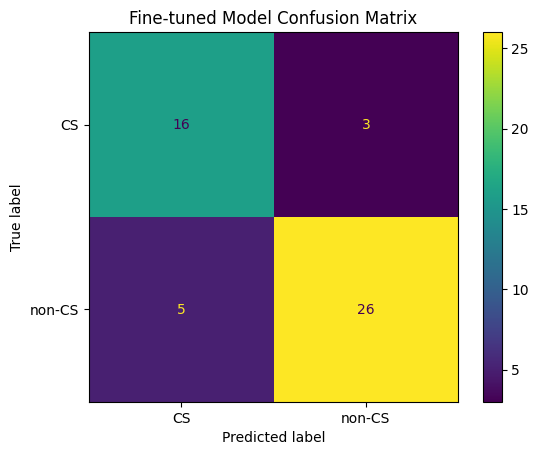

In [ ]:
# Metrikleri hesaplattırıp plot ettirelim
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Remove unknown predictions if any
valid_results_df = results_df[results_df["predicted_label"].isin(["CS", "non-CS"])].copy()

y_true = valid_results_df["true_label"]
y_pred = valid_results_df["predicted_label"]

accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="binary",
    pos_label="CS"
)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=["CS", "non-CS"]))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred, labels=["CS", "non-CS"])
print(pd.DataFrame(cm, index=["True CS", "True non-CS"], columns=["Pred CS", "Pred non-CS"]))


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["CS", "non-CS"]
)

disp.plot()
plt.title("Fine-tuned Model Confusion Matrix")
plt.show()

Gayet temel seviye bir Fine-tuning ile %84 F1-score elde etmiş olduk. CoT ile %80'de kalmıştık.

In [ ]:
def predict_manual(abstract, model, tokenizer):
    messages = [
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": (
                "Classify the following abstract as ComputerScience or Other:\n\n"
                f"{abstract}"
            )
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    new_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
    raw = tokenizer.decode(new_tokens, skip_special_tokens=True)

    return raw.strip()

In [ ]:
astro_abstract = """
We develope a self-consistent description of the Broad Line Region based on
the concept of the failed wind powered by the radiation pressure acting on
dusty accretion disk atmosphere in Keplerian motion...
"""

print(predict_manual(astro_abstract, model, tokenizer))

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


non.GraphicsUnit.GraphicsUnit.GraphicsUnit.GraphicsUnit.GraphicsUnit.GraphicsUnit.GraphicsUnit.GraphicsUnit.GraphicsUnit


# MODELİ LOKAL BİLGİSAYARIMDA NASIL SUNABİLİRİM? (Bu kısımda kaldık, dersin son 10dk'sı dondu, son 10 dk gelecek derste üstünden geçebiliriz)

*(Not:Ollama ile deployment aşaması kişisel bilgisayarımızın lokalinde manuel işlemler gerektirdiği için Colab notebook üzerinden değil uygulamalı olarak anlatacağım)*

Önce LoRA fine-tuning ile elde edilen kaydedilmiş safetensor ve config dosyasını lokale indirelim/taşıyalım.

Ardından indirdiğimiz dizinde aşağıdaki işlemleri gerçekleştirelim.


```
ollama pull meta-llama3:8b

git clone https://github.com/ggml-org/llama.cpp
cd llama.cpp

python convert_lora_to_gguf.py abstract_classifier_ollama/adapter  --outfile abstract_classifier_ollama/adapter.gguf

ollama create llama3-8b-qlora-abstract-classifier
ollama run llama3-8b-qlora-abstract-classifier
```




## LoRA Adapter'ı Ollama ile Lokalde Serve Etme

Bu bölümde fine-tuning sonucunda kaydettiğimiz LoRA adapter'ı lokal makinemizde Ollama üzerinden kullanılabilir hale getireceğiz.

Eğitim sonunda elimizde Hugging Face PEFT formatında bir LoRA adapter klasörü oluşur. Bu klasörde genellikle şu dosyalar bulunur:

```text
adapter_config.json
adapter_model.safetensors
tokenizer_config.json
tokenizer.json
```

Ancak Ollama bu PEFT adapter klasörünü her zaman doğrudan okuyamayabilir. Bu yüzden adapter'ı `GGUF` formatına çevirerek Ollama'nın anlayabileceği hale getireceğiz.

Genel akış şu şekildedir:

```text
LoRA fine-tuning
        ↓
PEFT adapter kaydı
        ↓
convert_lora_to_gguf.py
        ↓
adapter.gguf
        ↓
Modelfile
        ↓
ollama create
        ↓
lokal model servisi
```

### 1. llama.cpp reposunu indirme

LoRA adapter'ı GGUF formatına çevirmek için `llama.cpp` reposunda bulunan `convert_lora_to_gguf.py` script'ini kullanacağız.

Windows PowerShell üzerinde:

```powershell
cd .\Desktop\
git clone https://github.com/ggml-org/llama.cpp
cd llama.cpp
dir
```

### 2. Gerekli Python paketlerini kurma

Script çalışırken `transformers`, `torch` ve Hugging Face erişimi gerekebilir. Eğer ortamda kurulu değillerse:

```powershell
pip install transformers
pip install torch
```

### 3. LoRA adapter'ı GGUF formatına çevirme

Fine-tuning sonunda kaydedilen adapter klasörünün şu konumda olduğunu varsayalım:

```text
C:/Users/fisne/Desktop/abstract_classifier_ollama/adapter
```

Bu klasörün içinde en az şu iki dosya olmalıdır:

```text
adapter_config.json
adapter_model.safetensors
```

Şimdi adapter'ı GGUF formatına çevirelim:

```powershell
python convert_lora_to_gguf.py C:/Users/fisne/Desktop/abstract_classifier_ollama/adapter --outfile C:/Users/fisne/Desktop/abstract_classifier_ollama/adapter.gguf
```

Bu komut başarılı çalışırsa şu dosya oluşur:

```text
C:/Users/fisne/Desktop/abstract_classifier_ollama/adapter.gguf
```

Artık Ollama tarafında PEFT adapter klasörü yerine bu GGUF adapter dosyasını kullanacağız.

### 4. Ollama base modelini indirme

LoRA adapter hangi base model üzerinde eğitildiyse Ollama tarafında da aynı base model ailesi kullanılmalıdır.

Bu örnekte adapter şu model üzerinde eğitildi:

```text
meta-llama/Meta-Llama-3-8B-Instruct
```

Bu yüzden Ollama tarafında `llama3:8b` kullanacağız:

```powershell
ollama pull llama3:8b
```

Eğer adapter `Llama-3.1-8B-Instruct` üzerinde eğitilmiş olsaydı, o zaman `llama3.1:8b` kullanmak gerekirdi.

### 5. Modelfile oluşturma

Şimdi `C:/Users/fisne/Desktop/abstract_classifier_ollama/` klasöründe `Modelfile` adlı uzantısız bir dosya oluşturuyoruz.

Klasör yapısı şöyle olmalıdır:

```text
abstract_classifier_ollama/
├── Modelfile
├── adapter.gguf
└── adapter/
    ├── adapter_config.json
    └── adapter_model.safetensors
```

`Modelfile` içeriği:

```dockerfile
FROM llama3:8b

ADAPTER ./adapter.gguf

SYSTEM """
You are an academic abstract classifier.
Classify each abstract into exactly one label: ComputerScience or Other.
Use ComputerScience only if the main topic is clearly computer science, artificial intelligence, machine learning, algorithms, software, data science, computer systems, NLP, computer vision, databases, networks, or security.
Use Other if the abstract is mainly about physics, astronomy, biology, medicine, mathematics, statistics, finance, chemistry, or another scientific domain.
Answer with only one label.
"""

PARAMETER temperature 0
```

Burada `FROM llama3:8b` base modeli belirtir. `ADAPTER ./adapter.gguf` fine-tune ettiğimiz LoRA adapter'ı modele ekler. `SYSTEM` modelin görev tanımını belirler. `PARAMETER temperature 0` ise modelin daha deterministik cevap vermesini sağlar.

### 6. Ollama modelini oluşturma

PowerShell'de `Modelfile` dosyasının bulunduğu klasöre gidiyoruz:

```powershell
cd C:/Users/fisne/Desktop/abstract_classifier_ollama
```

Ardından Ollama modelini oluşturuyoruz:

```powershell
ollama create abstract-classifier
```

Bu komut başarılı olursa artık fine-tuned adapter bağlı modelimiz Ollama içinde `abstract-classifier` adıyla kullanılabilir hale gelir.

### 7. Modeli çalıştırma

Modeli terminalden çalıştırmak için:

```powershell
ollama run abstract-classifier
```

Örnek test:

```text
Classify the following abstract as ComputerScience or Other:

We develop a self-consistent description of the Broad Line Region based on the concept of the failed wind powered by radiation pressure acting on dusty accretion disk atmosphere in Keplerian motion.
```

Beklenen cevap:

```text
Other
```

Bir de Computer Science örneği:

```text
Classify the following abstract as ComputerScience or Other:

We propose a transformer-based neural network architecture for document classification and evaluate it on benchmark NLP datasets.
```

Beklenen cevap:

```text
ComputerScience
```

### 8. Özet

Bu adımda fine-tuning sonucunda elde ettiğimiz LoRA adapter'ı lokal bir uygulama haline getirdik.

Önce PEFT formatındaki adapter'ı GGUF formatına çevirdik. Daha sonra Ollama için bir `Modelfile` hazırladık. Son olarak `ollama create` komutuyla kendi fine-tuned modelimizi lokal makinede serve edilebilir hale getirdik.

Bu sayede model artık Python notebook'a bağlı kalmadan, terminalden veya Open WebUI gibi arayüzlerden lokal olarak kullanılabilir.

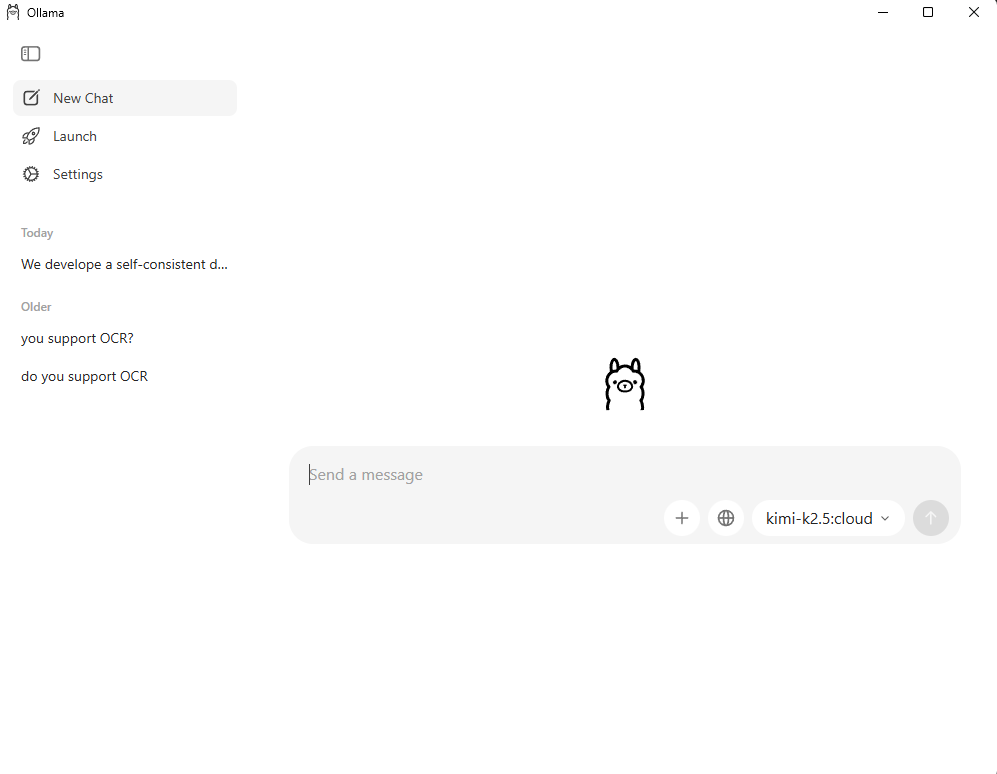

🦾 💻

Adımları doğru uygulayınca kendi fine-tuned dil modelimizi **offline** olarak (internet veya herhangi bir dış platforma ihtiyaç duymadan) kişisel bilgisayarımızda serve edebiliyor / kullanabiliyor olacağız.